In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/resume_dataset')

print("Extracted successfully!")

for root, dirs, files in os.walk('/content/resume_dataset'):
    for file in files:
        print(os.path.join(root, file))

Extracted successfully!
/content/resume_dataset/skills_list.csv
/content/resume_dataset/training_data.csv
/content/resume_dataset/test_resumes.json
/content/resume_dataset/skills_database.json
/content/resume_dataset/job_roles.csv


In [ ]:
import os
import pandas as pd

base = "/content/resume_dataset"

for root, dirs, files in os.walk(base):
    for file in files:
        path = os.path.join(root, file)

        print("\n" + "="*80)
        print("FILE:", file)

        try:
            if file.endswith(".csv"):
                df = pd.read_csv(path)
                print("Rows:", df.shape[0])
                print("Columns:", df.shape[1])
                print("Column names:")
                print(df.columns.tolist())
                print("\nFirst 2 rows:")
                display(df.head(2))

            elif file.endswith(".json"):
                import json
                with open(path, "r", encoding="utf-8") as f:
                    data = json.load(f)

                print("JSON type:", type(data))
                if isinstance(data, dict):
                    print("Keys:", list(data.keys())[:20])
                elif isinstance(data, list):
                    print("Number of records:", len(data))
                    print("First record:", data[0] if len(data) > 0 else "Empty")

        except Exception as e:
            print("ERROR:", e)


FILE: skills_list.csv
Rows: 120
Columns: 2
Column names:
['Skill Name', 'Category']

First 2 rows:


,Skill Name,Category
0,Python,Programming
1,Java,Programming



FILE: training_data.csv
Rows: 10000
Columns: 7
Column names:
['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills', 'Job Role', 'Category']

First 2 rows:


,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
0,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,2,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
1,R000001,Education: Master's in Microbiology Experience...,Master's in Microbiology,3,Agile|Data Analysis|Precision|Problem Solving|...,Microbiologist,Science & Research



FILE: test_resumes.json
JSON type: <class 'list'>
Number of records: 8
First record: {'name': 'Alice Johnson', 'description': 'Experienced full-stack software engineer with 5 years of expertise in building scalable web applications. Proficient in modern web technologies and cloud infrastructure. Proven track record of delivering high-quality code and leading technical initiatives.', 'resume_text': "Education: Bachelor's in Computer Science\nExperience: 5 years\nSkills: Python, JavaScript, React, Node.js, SQL, Docker, Kubernetes, AWS, Problem Solving, Teamwork", 'expected_roles': ['Full Stack Developer', 'Software Engineer', 'Backend Developer']}

FILE: skills_database.json
JSON type: <class 'dict'>
Keys: ['Programming', 'Web Development', 'Mobile Development', 'Cloud & DevOps', 'Data Science & Analytics', 'Database', 'Soft Skills', 'Business', 'Design', 'Cybersecurity', 'Professional']

FILE: job_roles.csv
Rows: 324
Columns: 6
Column names:
['Job Title', 'Category', 'Education Require

,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
0,Software Engineer,Technology,Bachelor's in Computer Science|Bachelor's in E...,2,Python|Java|C++|Git|Software Design|Problem So...,80-150K
1,Full Stack Developer,Technology,Diploma in IT|Bachelor's in Computer Science,2,JavaScript|React|Node.js|HTML/CSS|Database|Git,75-140K


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/resume_dataset/training_data.csv")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Job Roles:", df["Job Role"].nunique())

print("\nUnique Categories:", df["Category"].nunique())

print("\nCategories:")
print(df["Category"].value_counts())

print("\nTop 20 Job Roles:")
print(df["Job Role"].value_counts().head(20))

print("\nTop 20 Skills:")
skill_counts = (
    df["Skills"]
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
    .value_counts()
)

print(skill_counts.head(20))

Dataset Shape: (10000, 7)

Missing Values:
Resume ID           0
Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
Category            0
dtype: int64

Duplicate Rows: 0

Unique Job Roles: 324

Unique Categories: 42

Categories:
Category
Technology                      2511
Data & Analytics                 568
Healthcare                       488
Marketing & Sales                463
Engineering & Manufacturing      435
Creative & Design                334
Skilled Trades                   279
Operations & Supply Chain        266
Human Resources                  263
Finance & Accounting             252
Legal Services                   245
Retail & Hospitality             225
Entertainment & Media            194
Hospitality & Food Service       184
Education & Training             183
Beauty & Wellness                170
Private Sector Management        161
Law Enforcement                  161
Construction & Real Estate       159


Resume Length Statistics:
count    10000.000000
mean       168.549100
std         17.031113
min        105.000000
25%        156.000000
50%        168.000000
75%        180.000000
max        225.000000
Name: Resume_Length, dtype: float64

Experience Years:
Experience Years
0      820
1     1570
2     1830
3     1842
4     1758
5     1165
6      463
7      157
8      133
9       77
10      69
11      39
12      29
13      48
Name: count, dtype: int64

Skill Count Statistics:
count    10000.000000
mean         9.495300
std          1.108829
min          8.000000
25%          9.000000
50%          9.000000
75%         10.000000
max         11.000000
Name: Skill_Count, dtype: float64

Top 20 Skills:
Skills
Communication          4374
Problem Solving        4216
Leadership             1775
SQL                    1162
Safety                 1051
Creativity             1048
Research                979
Customer Service        911
Data Analysis           893
Python                  731
Project 

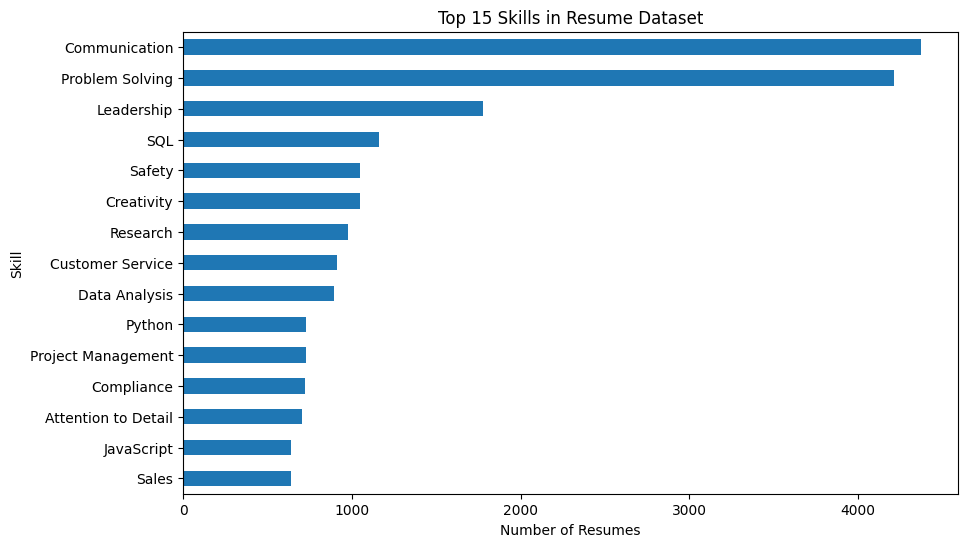

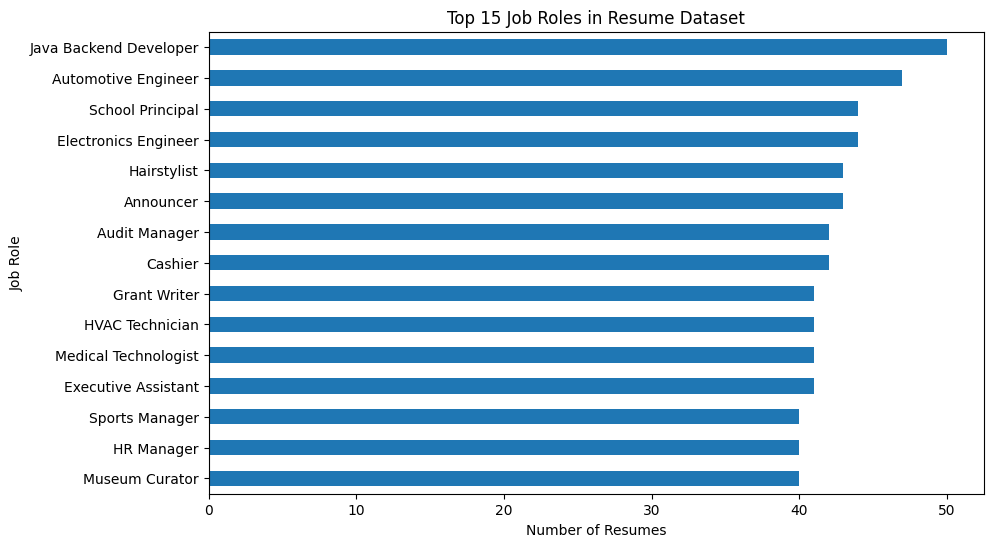

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Resume length
# -----------------------------
df["Resume_Length"] = df["Resume Text"].str.len()

print("Resume Length Statistics:")
print(df["Resume_Length"].describe())

# -----------------------------
# 2. Experience distribution
# -----------------------------
print("\nExperience Years:")
print(df["Experience Years"].value_counts().sort_index())

# -----------------------------
# 3. Skill count per resume
# -----------------------------
df["Skill_Count"] = df["Skills"].str.split("|").apply(len)

print("\nSkill Count Statistics:")
print(df["Skill_Count"].describe())

# -----------------------------
# 4. Top 20 Skills
# -----------------------------
skill_counts = (
    df["Skills"]
    .str.split("|")
    .explode()
    .str.strip()
    .value_counts()
)

print("\nTop 20 Skills:")
print(skill_counts.head(20))

# -----------------------------
# 5. Plot Top Skills
# -----------------------------
plt.figure(figsize=(10,6))
skill_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Skills in Resume Dataset")
plt.xlabel("Number of Resumes")
plt.ylabel("Skill")
plt.show()

# -----------------------------
# 6. Job Role Distribution
# -----------------------------
role_counts = df["Job Role"].value_counts()

plt.figure(figsize=(10,6))
role_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Job Roles in Resume Dataset")
plt.xlabel("Number of Resumes")
plt.ylabel("Job Role")
plt.show()

In [ ]:
# ============================================
# NLP SKILL EXTRACTION - REAL DATASET
# ============================================

import pandas as pd
import re

# Load dataset
df = pd.read_csv("/content/resume_dataset/training_data.csv")

# Load skill list
skills_df = pd.read_csv("/content/resume_dataset/skills_list.csv")

# Get all skills
skill_list = skills_df["Skill Name"].dropna().astype(str).str.strip().tolist()

print("Number of skills in skill dictionary:", len(skill_list))
print("First 20 skills:")
print(skill_list[:20])


# --------------------------------------------
# Text cleaning function
# --------------------------------------------

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9+#./ -]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# --------------------------------------------
# Skill extraction function
# --------------------------------------------

def extract_skills(resume_text, skill_list):

    text = clean_text(resume_text)

    detected_skills = []

    for skill in skill_list:

        skill_clean = clean_text(skill)

        # Exact word/phrase matching
        pattern = r"(?<!\w)" + re.escape(skill_clean) + r"(?!\w)"

        if re.search(pattern, text):
            detected_skills.append(skill)

    return sorted(set(detected_skills))


# --------------------------------------------
# Test with one real resume
# --------------------------------------------

sample_resume = df.loc[0, "Resume Text"]

print("\n========================================")
print("SAMPLE RESUME")
print("========================================")
print(sample_resume)

detected = extract_skills(sample_resume, skill_list)

print("\n========================================")
print("DETECTED SKILLS")
print("========================================")
print(detected)

print("\nNumber of detected skills:", len(detected))

Number of skills in skill dictionary: 120
First 20 skills:
['Python', 'Java', 'JavaScript', 'C++', 'C#', 'Ruby', 'PHP', 'Go', 'Rust', 'TypeScript', 'Kotlin', 'Swift', 'Scala', 'Perl', 'Shell Scripting', 'R', 'HTML', 'CSS', 'React', 'Vue.js']

SAMPLE RESUME
Education: Bachelor's in Computer Science Experience: 2 years Skills: Market Research, Maven, Java, REST API, Spring Boot, Microservices, Statistics, SQL

DETECTED SKILLS
['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']

Number of detected skills: 6


In [ ]:
# ============================================
# EXTRACT SKILLS FROM ALL 10,000 RESUMES
# ============================================

# Apply skill extraction to every resume
df["Extracted Skills"] = df["Resume Text"].apply(
    lambda x: extract_skills(x, skill_list)
)

# Number of extracted skills per resume
df["Extracted Skill Count"] = df["Extracted Skills"].apply(len)

print("Skill extraction completed!")
print("Total resumes processed:", len(df))

print("\n========================================")
print("FIRST 10 RESULTS")
print("========================================")

for i in range(10):
    print("\nResume ID:", df.loc[i, "Resume ID"])
    print("Job Role:", df.loc[i, "Job Role"])
    print("Extracted Skills:", df.loc[i, "Extracted Skills"])
    print("Skill Count:", df.loc[i, "Extracted Skill Count"])

# --------------------------------------------
# Overall statistics
# --------------------------------------------

print("\n========================================")
print("EXTRACTION STATISTICS")
print("========================================")

print("Average extracted skills per resume:",
      round(df["Extracted Skill Count"].mean(), 2))

print("Minimum skills in a resume:",
      df["Extracted Skill Count"].min())

print("Maximum skills in a resume:",
      df["Extracted Skill Count"].max())

# --------------------------------------------
# Save extracted dataset
# --------------------------------------------

output_file = "/content/resume_dataset/resumes_with_extracted_skills.csv"

df.to_csv(output_file, index=False)

print("\nSaved file:")
print(output_file)

Skill extraction completed!
Total resumes processed: 10000

FIRST 10 RESULTS

Resume ID: R000000
Job Role: Java Backend Developer
Extracted Skills: ['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']
Skill Count: 6

Resume ID: R000001
Job Role: Microbiologist
Extracted Skills: ['Agile', 'Business Development', 'Data Analysis', 'Problem Solving', 'Scala']
Skill Count: 5

Resume ID: R000002
Job Role: Plumber
Extracted Skills: ['Creativity', 'PostgreSQL', 'Problem Solving', 'React']
Skill Count: 4

Resume ID: R000003
Job Role: PHP Developer
Extracted Skills: ['CSS', 'Financial Analysis', 'HTML', 'MySQL', 'PHP', 'Query Optimization', 'Terraform']
Skill Count: 7

Resume ID: R000004
Job Role: Art Director
Extracted Skills: ['Ansible', 'Communication', 'Creativity', 'Docker', 'Leadership', 'Problem Solving', 'Scrum']
Skill Count: 7

Resume ID: R000005
Job Role: Executive Assistant
Extracted Skills: ['CI/CD', 'Communication', 'Database Design', 'Deep Learning', 'Probl

In [ ]:
# ============================================
# SKILL GAP ANALYSIS
# ============================================

# Load job roles dataset
job_roles_df = pd.read_csv(
    "/content/resume_dataset/job_roles.csv"
)

print("Total Job Roles:", len(job_roles_df))


# --------------------------------------------
# Convert required skills into sets
# --------------------------------------------

def parse_skills(skill_text):
    if pd.isna(skill_text):
        return set()

    return set(
        skill.strip().lower()
        for skill in str(skill_text).split("|")
        if skill.strip()
    )


job_roles_df["Required Skill Set"] = (
    job_roles_df["Required Skills"]
    .apply(parse_skills)
)


# --------------------------------------------
# Candidate skills
# --------------------------------------------

def get_candidate_skills(skills):
    return set(
        str(skill).strip().lower()
        for skill in skills
        if str(skill).strip()
    )


# --------------------------------------------
# Calculate skill gap
# --------------------------------------------

def calculate_skill_gap(candidate_skills, required_skills):

    candidate = get_candidate_skills(candidate_skills)

    matched = candidate.intersection(required_skills)
    missing = required_skills - candidate

    if len(required_skills) > 0:
        match_percentage = (
            len(matched) / len(required_skills)
        ) * 100
    else:
        match_percentage = 0

    return matched, missing, match_percentage


# --------------------------------------------
# Test with first resume
# --------------------------------------------

candidate_skills = df.loc[0, "Extracted Skills"]

print("\n========================================")
print("CANDIDATE")
print("========================================")

print("Resume ID:", df.loc[0, "Resume ID"])
print("Current Job Role:", df.loc[0, "Job Role"])

print("\nCandidate Skills:")
print(candidate_skills)


# --------------------------------------------
# Compare candidate with all job roles
# --------------------------------------------

recommendations = []

for _, role in job_roles_df.iterrows():

    required_skills = role["Required Skill Set"]

    matched, missing, score = calculate_skill_gap(
        candidate_skills,
        required_skills
    )

    recommendations.append({
        "Job Role": role["Job Title"],
        "Category": role["Category"],
        "Match Percentage": round(score, 2),
        "Matching Skills": ", ".join(sorted(matched)),
        "Missing Skills": ", ".join(sorted(missing)),
        "Required Skill Count": len(required_skills),
        "Matched Skill Count": len(matched)
    })


# Convert to DataFrame
recommendation_df = pd.DataFrame(recommendations)


# --------------------------------------------
# Top 10 career recommendations
# --------------------------------------------

top_recommendations = recommendation_df.sort_values(
    by="Match Percentage",
    ascending=False
).head(10)


print("\n========================================")
print("TOP 10 CAREER RECOMMENDATIONS")
print("========================================")

display(top_recommendations[
    [
        "Job Role",
        "Category",
        "Match Percentage",
        "Matching Skills",
        "Missing Skills"
    ]
])


# --------------------------------------------
# Best career
# --------------------------------------------

best = top_recommendations.iloc[0]

print("\n========================================")
print("BEST MATCH")
print("========================================")

print("Recommended Career:", best["Job Role"])
print("Match Percentage:", best["Match Percentage"], "%")
print("Matching Skills:", best["Matching Skills"])
print("Missing Skills:", best["Missing Skills"])

Total Job Roles: 324

CANDIDATE
Resume ID: R000000
Current Job Role: Java Backend Developer

Candidate Skills:
['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']

TOP 10 CAREER RECOMMENDATIONS


,Job Role,Category,Match Percentage,Matching Skills,Missing Skills
199,Java Backend Developer,Technology,66.67,"java, microservices, rest api, sql","maven, spring boot"
195,Python Developer,Technology,33.33,"rest api, sql","django, flask, problem solving, python"
224,Talend Developer,Data & Analytics,33.33,"java, sql","data integration, data quality, etl, talend"
6,Data Scientist,Technology,33.33,"sql, statistics","data analysis, machine learning, python, tenso..."
3,Backend Developer,Technology,33.33,"java, sql","api development, database design, node.js, python"
14,Mobile Developer Android,Technology,33.33,"java, rest api","android sdk, kotlin, mobile design, xml"
26,Financial Analyst,Finance & Accounting,16.67,statistics,"excel, financial modeling, python, risk analys..."
230,Tableau Specialist,Data & Analytics,16.67,sql,"analytics, communication, dashboard design, da..."
229,Qlik Developer,Data & Analytics,16.67,sql,"analytics, dashboard development, data visuali..."
228,Looker Developer,Data & Analytics,16.67,sql,"analytics, dashboard development, data visuali..."



BEST MATCH
Recommended Career: Java Backend Developer
Match Percentage: 66.67 %
Matching Skills: java, microservices, rest api, sql
Missing Skills: maven, spring boot


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "job" in file.lower():
            print(os.path.join(root, file))

/content/job_titles.csv
/content/resume_dataset/job_roles.csv


In [ ]:
import pandas as pd
import os

job_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv") and "job" in file.lower():
            job_files.append(os.path.join(root, file))

for file in job_files:

    print("\n" + "="*80)
    print("FILE:", file)

    data = pd.read_csv(file)

    print("Shape:", data.shape)
    print("Columns:")
    print(data.columns.tolist())

    display(data.head(3))


FILE: /content/job_titles.csv
Shape: (54269, 5)
Columns:
['O*NET-SOC Code', 'Title', 'Job Title', 'Short Title', 'Source(s)']


,O*NET-SOC Code,Title,Job Title,Short Title,Source(s)
0,11-1011.00,Chief Executives,Aeronautics Commission Director,NaN,08
1,11-1011.00,Chief Executives,Agency Owner,NaN,10
2,11-1011.00,Chief Executives,Agricultural Services Director,NaN,08



FILE: /content/resume_dataset/job_roles.csv
Shape: (324, 6)
Columns:
['Job Title', 'Category', 'Education Requirement', 'Experience Years', 'Required Skills', 'Salary Range']


,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
0,Software Engineer,Technology,Bachelor's in Computer Science|Bachelor's in E...,2,Python|Java|C++|Git|Software Design|Problem So...,80-150K
1,Full Stack Developer,Technology,Diploma in IT|Bachelor's in Computer Science,2,JavaScript|React|Node.js|HTML/CSS|Database|Git,75-140K
2,Frontend Developer,Technology,Diploma in IT|Bachelor's in Computer Science,1,JavaScript|React|Vue.js|CSS|HTML|UI/UX Design,70-130K


In [ ]:
import os

print("All CSV files found:\n")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".csv", ".json", ".xlsx")):
            print(os.path.join(root, file))

All CSV files found:

/content/software_skills.csv
/content/job_titles.csv
/content/occupation_data.csv
/content/.config/.last_update_check.json
/content/resume_dataset/skills_list.csv
/content/resume_dataset/training_data.csv
/content/resume_dataset/resumes_with_extracted_skills.csv
/content/resume_dataset/test_resumes.json
/content/resume_dataset/skills_database.json
/content/resume_dataset/job_roles.csv
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

/content/software_skills.csv
/content/job_titles.csv
/content/occupation_data.csv
/content/resume_dataset/skills_list.csv
/content/resume_dataset/training_data.csv
/content/resume_dataset/resumes_with_extracted_skills.csv
/content/resume_dataset/job_roles.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (2) (1).zip to archive (2) (1) (1).zip


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

/content/software_skills.csv
/content/job_titles.csv
/content/occupation_data.csv
/content/resume_dataset/skills_list.csv
/content/resume_dataset/training_data.csv
/content/resume_dataset/resumes_with_extracted_skills.csv
/content/resume_dataset/job_roles.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [ ]:
import zipfile
import os

zip_path = "/content/archive (2) (1).zip"
extract_path = "/content/job_market_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os

for root, dirs, files in os.walk("/content/job_market_dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/job_market_dataset/job_description.csv
/content/job_market_dataset/job_postings.csv


In [ ]:
import pandas as pd

job_description = pd.read_csv("/content/job_market_dataset/job_description.csv")
job_postings = pd.read_csv("/content/job_market_dataset/job_postings.csv")

print("JOB DESCRIPTION")
print("Shape:", job_description.shape)
print("Columns:", job_description.columns.tolist())
print()

print("JOB POSTINGS")
print("Shape:", job_postings.shape)
print("Columns:", job_postings.columns.tolist())

JOB DESCRIPTION
Shape: (325, 6)
Columns: ['Unnamed: 0', 'Category', 'Description', 'Benefits', 'Requirement', 'Requirements']

JOB POSTINGS
Shape: (1095, 6)
Columns: ['Unnamed: 0', 'Category', 'Workplace', 'Location', 'Department', 'Type']


In [ ]:
import pandas as pd
import re
from collections import Counter

# Load job market datasets
job_description = pd.read_csv(
    "/content/job_market_dataset/job_description.csv"
)

job_postings = pd.read_csv(
    "/content/job_market_dataset/job_postings.csv"
)

# Combine the useful text fields
text_columns = ["Description", "Benefits", "Requirement", "Requirements"]

for col in text_columns:
    job_description[col] = job_description[col].fillna("").astype(str)

job_description["Job Text"] = (
    job_description["Description"] + " " +
    job_description["Benefits"] + " " +
    job_description["Requirement"] + " " +
    job_description["Requirements"]
)

print("Total Job Descriptions:", len(job_description))
print()
print("Sample Job Text:")
print(job_description["Job Text"].iloc[0][:1000])

Total Job Descriptions: 325

Sample Job Text:
Description
Job Title: Junior Business Analyst
Location: Home-based (This role will require regular UK travel and at times need you to stay away from home)
Start Date: May (To be confirmed)
Methods is a £100M+ IT Services Consultancy who has partnered with a range of central government departments and agencies to transform the way the public sector operates in the UK. Established over 30 years ago and UK-based, we apply our skills in transformation, delivery, and collaboration from across the Methods Group, to create end-to-end business and technical solutions that are people-centred, safe, and designed for the future.
Our human touch sets us apart from other consultancies, system integrators and software houses - with people, technology, and data at the heart of who we are, we believe in creating value and sustainability through everything we do for our clients, staff, communities, and the planet.
We support our clients in the success of t

In [ ]:
# Use the same skill list from the resume dataset
skills_df = pd.read_csv("/content/resume_dataset/skills_list.csv")

skill_list = skills_df["Skill Name"].dropna().tolist()

print("Total Skills in Taxonomy:", len(skill_list))
print("First 20 Skills:")
print(skill_list[:20])


# Skill extraction function
def extract_job_skills(text, skill_list):
    text = str(text).lower()
    found_skills = []

    for skill in skill_list:
        skill_lower = skill.lower()

        # Exact phrase matching
        pattern = r'(?<!\w)' + re.escape(skill_lower) + r'(?!\w)'

        if re.search(pattern, text):
            found_skills.append(skill)

    return sorted(set(found_skills))


# Extract skills from every job description
job_description["Extracted Skills"] = job_description["Job Text"].apply(
    lambda x: extract_job_skills(x, skill_list)
)

# Count extracted skills
job_description["Skill Count"] = job_description["Extracted Skills"].apply(len)

print("\nSkill extraction completed!")

print("\nFirst 10 job descriptions with extracted skills:")
print(
    job_description[
        ["Category", "Extracted Skills", "Skill Count"]
    ].head(10).to_string(index=False)
)

Total Skills in Taxonomy: 120
First 20 Skills:
['Python', 'Java', 'JavaScript', 'C++', 'C#', 'Ruby', 'PHP', 'Go', 'Rust', 'TypeScript', 'Kotlin', 'Swift', 'Scala', 'Perl', 'Shell Scripting', 'R', 'HTML', 'CSS', 'React', 'Vue.js']

Skill extraction completed!

First 10 job descriptions with extracted skills:
        Category                                                                                 Extracted Skills  Skill Count
Business Analyst [Communication, Documentation, Leadership, Problem Solving, Project Management, Time Management]            6
Business Analyst                                                            [Communication, Documentation, Sales]            3
Business Analyst                                                                                          [Agile]            1
Business Analyst                                  [Agile, Confluence, Jira, Marketing, Project Management, Sales]            6
Business Analyst                                        

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Count how many job descriptions require each skill
skill_demand = Counter()

for skills in job_description["Extracted Skills"]:
    for skill in skills:
        skill_demand[skill] += 1

# Convert to DataFrame
market_skills = pd.DataFrame(
    skill_demand.items(),
    columns=["Skill", "Job_Count"]
)

# Sort by demand
market_skills = market_skills.sort_values(
    by="Job_Count",
    ascending=False
).reset_index(drop=True)

# Calculate percentage of job descriptions
market_skills["Demand_Percentage"] = (
    market_skills["Job_Count"] / len(job_description) * 100
).round(2)

print("Top 20 In-Demand Skills:\n")
print(market_skills.head(20).to_string(index=False))

Top 20 In-Demand Skills:

             Skill  Job_Count  Demand_Percentage
     Communication        189              58.15
            Python        113              34.77
               SQL         91              28.00
             Agile         90              27.69
  Machine Learning         86              26.46
     Documentation         83              25.54
        Leadership         74              22.77
        Statistics         60              18.46
               AWS         57              17.54
             Azure         52              16.00
     Data Analysis         45              13.85
        Compliance         43              13.23
                Go         40              12.31
                 R         38              11.69
         Marketing         37              11.38
Project Management         36              11.08
        JavaScript         35              10.77
             Sales         34              10.46
             Scrum         33              

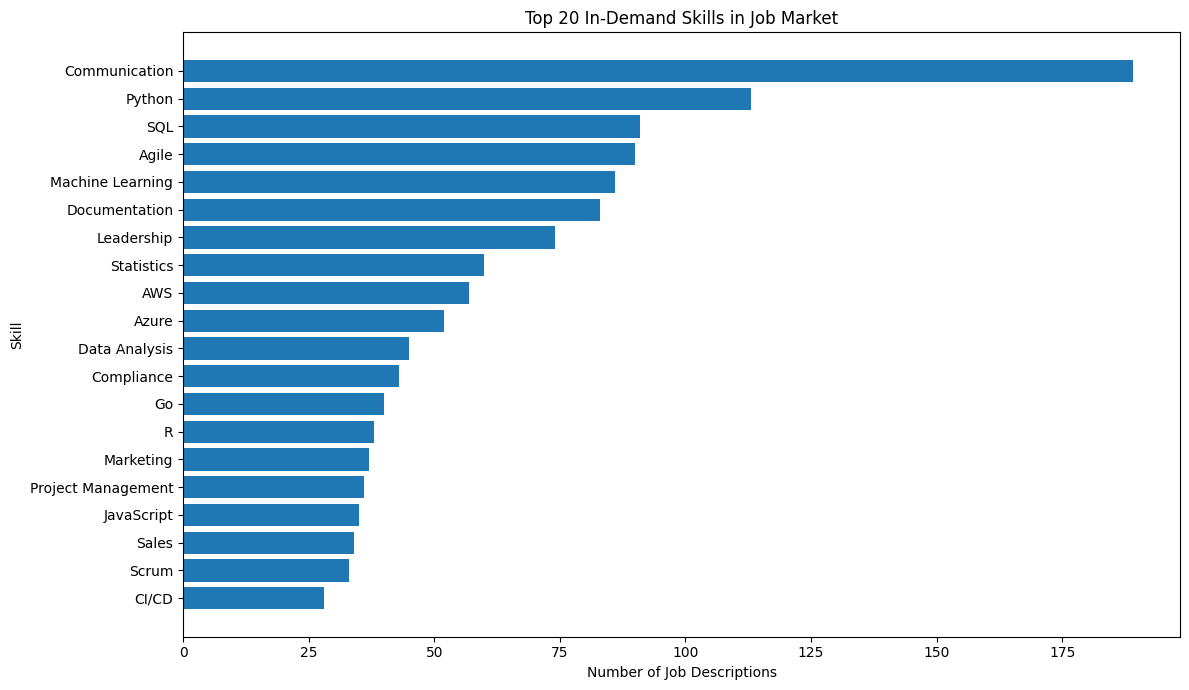

In [ ]:
top20 = market_skills.head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["Skill"][::-1],
    top20["Job_Count"][::-1]
)

plt.xlabel("Number of Job Descriptions")
plt.ylabel("Skill")
plt.title("Top 20 In-Demand Skills in Job Market")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

job_roles = pd.read_csv("/content/resume_dataset/job_roles.csv")

print("Job Roles loaded:", job_roles.shape)
print("Columns:", job_roles.columns.tolist())

Job Roles loaded: (324, 6)
Columns: ['Job Title', 'Category', 'Education Requirement', 'Experience Years', 'Required Skills', 'Salary Range']


In [ ]:
# ==========================================
# DYNAMIC CAREER RECOMMENDATION
# Skill Match + Job Market Demand
# ==========================================

# Create a dictionary for market demand
market_demand_dict = dict(
    zip(
        market_skills["Skill"].str.lower(),
        market_skills["Demand_Percentage"]
    )
)

# Function to calculate market score for a job role
def calculate_market_score(required_skills):
    if not required_skills:
        return 0

    scores = []

    for skill in required_skills:
        skill_lower = skill.lower()

        if skill_lower in market_demand_dict:
            scores.append(market_demand_dict[skill_lower])
        else:
            scores.append(0)

    return sum(scores) / len(scores)


# Calculate dynamic score for each recommended role
dynamic_results = []

candidate_skills = set(
    skill.lower()
    for skill in df.loc[0, "Extracted Skills"]
)

for _, role in job_roles.iterrows():

    required_skills = [
        skill.strip()
        for skill in str(role["Required Skills"]).split("|")
        if skill.strip()
    ]

    required_lower = set(
        skill.lower()
        for skill in required_skills
    )

    # Skill matching
    matched = candidate_skills.intersection(required_lower)

    if len(required_lower) > 0:
        skill_match = (
            len(matched) / len(required_lower)
        ) * 100
    else:
        skill_match = 0

    # Market demand
    market_score = calculate_market_score(required_skills)

    # Dynamic recommendation score
    dynamic_score = (
        0.7 * skill_match +
        0.3 * market_score
    )

    dynamic_results.append({
        "Job Role": role["Job Title"],
        "Skill Match": round(skill_match, 2),
        "Market Demand": round(market_score, 2),
        "Dynamic Score": round(dynamic_score, 2),
        "Matching Skills": ", ".join(sorted(matched))
    })


# Convert to DataFrame
dynamic_recommendations = pd.DataFrame(dynamic_results)

# Sort by Dynamic Score
dynamic_recommendations = dynamic_recommendations.sort_values(
    by="Dynamic Score",
    ascending=False
).reset_index(drop=True)

print("TOP 10 DYNAMIC CAREER RECOMMENDATIONS")
print("=" * 70)

print(
    dynamic_recommendations.head(10).to_string(index=False)
)

TOP 10 DYNAMIC CAREER RECOMMENDATIONS
                 Job Role  Skill Match  Market Demand  Dynamic Score                    Matching Skills
   Java Backend Developer        66.67           6.77          48.70 java, microservices, rest api, sql
           Data Scientist        33.33          21.49          29.78                    sql, statistics
        Backend Developer        33.33          12.26          27.01                          java, sql
         Python Developer        33.33          11.69          26.84                      rest api, sql
         Talend Developer        33.33           6.00          25.13                          java, sql
 Mobile Developer Android        33.33           1.64          23.83                     java, rest api
       Tableau Specialist        16.67          15.59          16.34                                sql
             Data Analyst        16.67          11.69          15.17                                sql
Machine Learning Engineer 

In [ ]:
# ==========================================
# EXPLAINABLE CAREER RECOMMENDATIONS
# ==========================================

explainable_results = []

# Candidate skills
candidate_skills = set(
    skill.lower()
    for skill in df.loc[0, "Extracted Skills"]
)

for _, role in dynamic_recommendations.head(10).iterrows():

    job_title = role["Job Role"]

    # Get the original role information
    role_info = job_roles[
        job_roles["Job Title"] == job_title
    ].iloc[0]

    required_skills = [
        skill.strip()
        for skill in str(role_info["Required Skills"]).split("|")
        if skill.strip()
    ]

    required_lower = set(
        skill.lower()
        for skill in required_skills
    )

    # Matching and missing skills
    matching = candidate_skills.intersection(required_lower)
    missing = required_lower - candidate_skills

    # Convert names back to readable format
    matching_display = [
        skill for skill in required_skills
        if skill.lower() in matching
    ]

    missing_display = [
        skill for skill in required_skills
        if skill.lower() in missing
    ]

    # Explanation
    if role["Dynamic Score"] == dynamic_recommendations.iloc[0]["Dynamic Score"]:
        explanation = (
            "Top recommendation because the candidate has a strong "
            "skill match and the required skills have relevant market demand."
        )
    elif role["Market Demand"] > role["Skill Match"]:
        explanation = (
            "Recommended because the role has relatively strong market "
            "demand, although the candidate needs additional skills."
        )
    else:
        explanation = (
            "Recommended mainly because the candidate already has "
            "several required skills."
        )

    explainable_results.append({
        "Job Role": job_title,
        "Skill Match (%)": role["Skill Match"],
        "Market Demand (%)": role["Market Demand"],
        "Dynamic Score": role["Dynamic Score"],
        "Matching Skills": ", ".join(matching_display),
        "Missing Skills": ", ".join(missing_display),
        "Explanation": explanation
    })


# Create final explainable table
explainable_df = pd.DataFrame(explainable_results)

print("EXPLAINABLE CAREER RECOMMENDATIONS")
print("=" * 100)

print(
    explainable_df.to_string(index=False)
)

EXPLAINABLE CAREER RECOMMENDATIONS
                 Job Role  Skill Match (%)  Market Demand (%)  Dynamic Score                    Matching Skills                                                          Missing Skills                                                                                                            Explanation
   Java Backend Developer            66.67               6.77          48.70 Java, SQL, REST API, Microservices                                                      Spring Boot, Maven Top recommendation because the candidate has a strong skill match and the required skills have relevant market demand.
           Data Scientist            33.33              21.49          29.78                    Statistics, SQL                     Python, Machine Learning, TensorFlow, Data Analysis                                          Recommended mainly because the candidate already has several required skills.
        Backend Developer            33.33              

In [ ]:
import pandas as pd

# Load O*NET datasets
onet_software = pd.read_csv("/content/software_skills.csv")
onet_occupation = pd.read_csv("/content/occupation_data.csv")
onet_titles = pd.read_csv("/content/job_titles.csv")

print("O*NET SOFTWARE SKILLS")
print("Shape:", onet_software.shape)
print("Columns:", onet_software.columns.tolist())

print("\nO*NET OCCUPATION DATA")
print("Shape:", onet_occupation.shape)
print("Columns:", onet_occupation.columns.tolist())

print("\nO*NET JOB TITLES")
print("Shape:", onet_titles.shape)
print("Columns:", onet_titles.columns.tolist())

O*NET SOFTWARE SKILLS
Shape: (31821, 7)
Columns: ['O*NET-SOC Code', 'Title', 'Workplace Example', 'Element ID', 'Element Name', 'Hot Technology', 'In Demand']

O*NET OCCUPATION DATA
Shape: (1016, 3)
Columns: ['O*NET-SOC Code', 'Title', 'Description']

O*NET JOB TITLES
Shape: (54269, 5)
Columns: ['O*NET-SOC Code', 'Title', 'Job Title', 'Short Title', 'Source(s)']


In [ ]:
# ==========================================
# O*NET OCCUPATION MATCHING
# ==========================================

# Recommended roles from our system
recommended_roles = dynamic_recommendations.head(10)["Job Role"].tolist()

# Function to find O*NET occupation matches
def find_onet_occupation(job_role):
    role_words = set(
        re.findall(r'\b[a-zA-Z]+\b', job_role.lower())
    )

    matches = []

    for _, row in onet_occupation.iterrows():

        title = str(row["Title"]).lower()

        title_words = set(
            re.findall(r'\b[a-zA-Z]+\b', title)
        )

        # Word overlap
        overlap = len(role_words.intersection(title_words))

        if overlap > 0:
            matches.append({
                "Job Role": job_role,
                "O*NET Title": row["Title"],
                "O*NET-SOC Code": row["O*NET-SOC Code"],
                "Description": row["Description"],
                "Word Overlap": overlap
            })

    return matches


# Collect matches
onet_matches = []

for role in recommended_roles:
    onet_matches.extend(find_onet_occupation(role))


# Convert to DataFrame
onet_matches_df = pd.DataFrame(onet_matches)

# Keep strongest matches
onet_matches_df = (
    onet_matches_df
    .sort_values(
        ["Job Role", "Word Overlap"],
        ascending=[True, False]
    )
    .groupby("Job Role")
    .head(3)
    .reset_index(drop=True)
)

print("TOP O*NET OCCUPATION MATCHES")
print("=" * 100)

print(
    onet_matches_df[
        ["Job Role", "O*NET Title", "O*NET-SOC Code", "Word Overlap"]
    ].to_string(index=False)
)

TOP O*NET OCCUPATION MATCHES
                 Job Role                                                               O*NET Title O*NET-SOC Code  Word Overlap
             Data Analyst                                              Data Warehousing Specialists     15-1243.01             1
             Data Analyst                                                           Data Scientists     15-2051.00             1
             Data Analyst                                                    Clinical Data Managers     15-2051.02             1
           Data Scientist                                              Data Warehousing Specialists     15-1243.01             1
           Data Scientist                                                           Data Scientists     15-2051.00             1
           Data Scientist                                                    Clinical Data Managers     15-2051.02             1
Machine Learning Engineer Postal Service Mail Sorters, Processors, a

In [ ]:
# ==========================================
# IMPROVED O*NET ROLE MATCHING
# ==========================================

# Important keywords for technical career roles
role_keywords = {
    "Java Backend Developer": ["software", "developer", "programmer"],
    "Backend Developer": ["software", "developer", "programmer"],
    "Python Developer": ["software", "developer", "programmer"],
    "Data Scientist": ["data scientist", "data"],
    "Data Analyst": ["data analyst", "data", "analyst"],
    "Machine Learning Engineer": ["machine learning", "data scientist", "software"],
    "Mobile Developer Android": ["software developer", "software", "mobile"],
    "Tableau Specialist": ["data", "analyst", "business intelligence"],
    "Spark Developer": ["data", "software", "developer"],
    "Talend Developer": ["data", "software", "developer"]
}

onet_results = []

for role in recommended_roles:

    title = role.lower()

    # Get important keywords
    keywords = role_keywords.get(role, [])

    candidate_matches = []

    for _, row in onet_occupation.iterrows():

        onet_title = str(row["Title"]).lower()

        score = 0

        # Exact/phrase matching gets higher score
        for keyword in keywords:

            if keyword in onet_title:
                if " " in keyword:
                    score += 3
                else:
                    score += 1

        if score > 0:
            candidate_matches.append({
                "Job Role": role,
                "O*NET Title": row["Title"],
                "O*NET-SOC Code": row["O*NET-SOC Code"],
                "Match Score": score,
                "Description": row["Description"]
            })

    # Keep strongest 3 matches
    candidate_matches = sorted(
        candidate_matches,
        key=lambda x: x["Match Score"],
        reverse=True
    )[:3]

    onet_results.extend(candidate_matches)


onet_matches_df = pd.DataFrame(onet_results)

print("IMPROVED O*NET OCCUPATION MATCHES")
print("=" * 100)

print(
    onet_matches_df[
        ["Job Role", "O*NET Title", "O*NET-SOC Code", "Match Score"]
    ].to_string(index=False)
)

IMPROVED O*NET OCCUPATION MATCHES
                 Job Role                                        O*NET Title O*NET-SOC Code  Match Score
   Java Backend Developer                                Software Developers     15-1252.00            2
   Java Backend Developer                               Computer Programmers     15-1251.00            1
   Java Backend Developer    Software Quality Assurance Analysts and Testers     15-1253.00            1
           Data Scientist                                    Data Scientists     15-2051.00            4
           Data Scientist                            Database Administrators     15-1242.00            1
           Data Scientist                                Database Architects     15-1243.00            1
        Backend Developer                                Software Developers     15-1252.00            2
        Backend Developer                               Computer Programmers     15-1251.00            1
        Backend Devel

In [ ]:
# ==========================================
# O*NET TECHNOLOGY SKILLS FOR RECOMMENDED ROLES
# ==========================================

# Take the strongest O*NET match for each recommended role
best_onet_matches = (
    onet_matches_df
    .sort_values(
        ["Job Role", "Match Score"],
        ascending=[True, False]
    )
    .groupby("Job Role")
    .first()
    .reset_index()
)

onet_technology_results = []

for _, row in best_onet_matches.iterrows():

    role = row["Job Role"]
    onet_code = row["O*NET-SOC Code"]

    # Get technologies for this occupation
    technologies = onet_software[
        onet_software["O*NET-SOC Code"] == onet_code
    ].copy()

    # Hot technologies
    hot_tech = technologies[
        technologies["Hot Technology"].astype(str).str.lower() == "yes"
    ]["Element Name"].dropna().unique().tolist()

    # In-demand technologies
    in_demand_tech = technologies[
        technologies["In Demand"].astype(str).str.lower() == "yes"
    ]["Element Name"].dropna().unique().tolist()

    onet_technology_results.append({
        "Job Role": role,
        "O*NET Title": row["O*NET Title"],
        "O*NET-SOC Code": onet_code,
        "Hot Technologies": ", ".join(hot_tech[:10]),
        "In-Demand Technologies": ", ".join(in_demand_tech[:10])
    })


onet_technology_df = pd.DataFrame(onet_technology_results)

print("O*NET TECHNOLOGY INFORMATION")
print("=" * 120)

print(
    onet_technology_df.to_string(index=False)
)

O*NET TECHNOLOGY INFORMATION
                 Job Role                    O*NET Title O*NET-SOC Code Hot Technologies In-Demand Technologies
        Backend Developer            Software Developers     15-1252.00                                        
             Data Analyst             Logistics Analysts     13-1081.02                                        
           Data Scientist                Data Scientists     15-2051.00                                        
   Java Backend Developer            Software Developers     15-1252.00                                        
Machine Learning Engineer                Data Scientists     15-2051.00                                        
 Mobile Developer Android            Software Developers     15-1252.00                                        
         Python Developer            Software Developers     15-1252.00                                        
          Spark Developer            Software Developers     15-1252.00    

In [ ]:
print("Hot Technology values:")
print(onet_software["Hot Technology"].value_counts(dropna=False).head(20))

print("\nIn Demand values:")
print(onet_software["In Demand"].value_counts(dropna=False).head(20))

print("\nSample O*NET software records:")
print(
    onet_software[
        ["Title", "Element Name", "Hot Technology", "In Demand"]
    ].head(20).to_string(index=False)
)

Hot Technology values:
Hot Technology
N    20250
Y    11571
Name: count, dtype: int64

In Demand values:
In Demand
N    29396
Y     2425
Name: count, dtype: int64

Sample O*NET software records:
           Title                                  Element Name Hot Technology In Demand
Chief Executives                  Document management software              Y         N
Chief Executives   Data base user interface and query software              N         N
Chief Executives                     Content workflow software              Y         N
Chief Executives Customer relationship management CRM software              N         N
Chief Executives                           Accounting software              N         N
Chief Executives                  Data base reporting software              N         N
Chief Executives   Data base user interface and query software              N         N
Chief Executives                      Electronic mail software              N         N
Chief Executi

In [ ]:
# ==========================================
# CORRECT O*NET TECHNOLOGY EXTRACTION
# ==========================================

onet_technology_results = []

for _, row in best_onet_matches.iterrows():

    role = row["Job Role"]
    onet_code = row["O*NET-SOC Code"]

    # Get technologies for this occupation
    technologies = onet_software[
        onet_software["O*NET-SOC Code"] == onet_code
    ].copy()

    # Hot technologies = Y
    hot_tech = technologies[
        technologies["Hot Technology"].astype(str).str.upper() == "Y"
    ]["Element Name"].dropna().unique().tolist()

    # In-demand technologies = Y
    in_demand_tech = technologies[
        technologies["In Demand"].astype(str).str.upper() == "Y"
    ]["Element Name"].dropna().unique().tolist()

    onet_technology_results.append({
        "Job Role": role,
        "O*NET Title": row["O*NET Title"],
        "O*NET-SOC Code": onet_code,
        "Hot Technologies": ", ".join(hot_tech[:10]),
        "In-Demand Technologies": ", ".join(in_demand_tech[:10])
    })


onet_technology_df = pd.DataFrame(onet_technology_results)

print("CORRECTED O*NET TECHNOLOGY INFORMATION")
print("=" * 130)

print(
    onet_technology_df.to_string(index=False)
)

CORRECTED O*NET TECHNOLOGY INFORMATION
                 Job Role                    O*NET Title O*NET-SOC Code                                                                                                                                                                                                                                                                                                                                                             Hot Technologies                                                                                                                                                                                                                                                                                                                                                              In-Demand Technologies
        Backend Developer            Software Developers     15-1252.00          Document management software, Video creation and editing software, Grap

In [ ]:
# ==========================================
# SAVE PROJECT RESULTS
# ==========================================

import os

output_dir = "/content/project_results"
os.makedirs(output_dir, exist_ok=True)

# Save extracted resume data
df.to_csv(
    f"{output_dir}/resume_skill_extraction.csv",
    index=False
)

# Save job market skill trends
market_skills.to_csv(
    f"{output_dir}/job_market_skill_trends.csv",
    index=False
)

# Save dynamic recommendations
dynamic_recommendations.to_csv(
    f"{output_dir}/dynamic_career_recommendations.csv",
    index=False
)

# Save explainable recommendations
explainable_df.to_csv(
    f"{output_dir}/explainable_recommendations.csv",
    index=False
)

# Save O*NET occupation matches
onet_matches_df.to_csv(
    f"{output_dir}/onet_occupation_matches.csv",
    index=False
)

# Save O*NET technology information
onet_technology_df.to_csv(
    f"{output_dir}/onet_technology_information.csv",
    index=False
)

print("All project results saved successfully!")
print("\nFiles saved in:")
print(output_dir)

print("\nSaved files:")
for file in os.listdir(output_dir):
    print("-", file)

All project results saved successfully!

Files saved in:
/content/project_results

Saved files:
- resume_skill_extraction.csv
- onet_occupation_matches.csv
- onet_technology_information.csv
- explainable_recommendations.csv
- dynamic_career_recommendations.csv
- job_market_skill_trends.csv


In [ ]:
# ==========================================
# SKILL EXTRACTION EVALUATION
# ==========================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Load extracted resume results
eval_df = pd.read_csv(
    "/content/project_results/resume_skill_extraction.csv"
)

# Convert skill list strings back to Python lists
import ast

eval_df["Extracted Skills"] = eval_df["Extracted Skills"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Load the original skill taxonomy
skills_df = pd.read_csv(
    "/content/resume_dataset/skills_list.csv"
)

skill_taxonomy = set(
    skills_df["Skill Name"].str.lower().str.strip()
)

# Convert original dataset skills into taxonomy-based ground truth
def get_ground_truth_skills(skill_text):
    if pd.isna(skill_text):
        return []

    skills = [
        s.strip()
        for s in str(skill_text).split(",")
    ]

    return [
        s for s in skills
        if s.lower() in skill_taxonomy
    ]

eval_df["Ground Truth Skills"] = eval_df["Skills"].apply(
    get_ground_truth_skills
)

# Calculate Precision, Recall and F1 for every resume
precisions = []
recalls = []
f1_scores = []

for _, row in eval_df.iterrows():

    true_skills = set(
        s.lower() for s in row["Ground Truth Skills"]
    )

    predicted_skills = set(
        s.lower() for s in row["Extracted Skills"]
    )

    all_skills = sorted(
        true_skills.union(predicted_skills)
    )

    if len(all_skills) == 0:
        continue

    y_true = [
        1 if skill in true_skills else 0
        for skill in all_skills
    ]

    y_pred = [
        1 if skill in predicted_skills else 0
        for skill in all_skills
    ]

    precisions.append(
        precision_score(y_true, y_pred, zero_division=0)
    )

    recalls.append(
        recall_score(y_true, y_pred, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_true, y_pred, zero_division=0)
    )

# Overall macro averages
precision_avg = sum(precisions) / len(precisions)
recall_avg = sum(recalls) / len(recalls)
f1_avg = sum(f1_scores) / len(f1_scores)

print("==========================================")
print("SKILL EXTRACTION EVALUATION")
print("==========================================")

print(f"Precision : {precision_avg:.4f}")
print(f"Recall    : {recall_avg:.4f}")
print(f"F1-Score  : {f1_avg:.4f}")

print("\nPercentage:")
print(f"Precision : {precision_avg * 100:.2f}%")
print(f"Recall    : {recall_avg * 100:.2f}%")
print(f"F1-Score  : {f1_avg * 100:.2f}%")

SKILL EXTRACTION EVALUATION
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000

Percentage:
Precision : 0.00%
Recall    : 0.00%
F1-Score  : 0.00%


In [ ]:
# Check the original Skills format

print("Sample Skills values:")
for value in df["Skills"].head(10):
    print(value)

Sample Skills values:
Market Research|Maven|Java|REST API|Spring Boot|Microservices|Statistics|SQL
Agile|Data Analysis|Precision|Problem Solving|Scala|Research|Business Development|Microbiology|Laboratory Work
React|Customer Service|Technical Knowledge|Plumbing Systems|Problem Solving|PostgreSQL|Code Knowledge|Creativity|Safety|iOS
MySQL|Query Optimization|Symfony|Terraform|PHP|HTML/CSS|API Development|Financial Analysis|Web Accessibility|Laravel|C++
Problem Solving|Docker|Creativity|Scrum|Ansible|Communication|Team Leadership|Design Principles|Artistic Direction|Visual Communication
CI/CD|Problem Solving|Database Design|PyTorch|Deep Learning|Communication|Executive Support|Discretion|Organization|Leadership Support|Creativity
Distributed Systems|CQL|Cassandra|Performance|NoSQL|Scalability|Business Development|Machine Learning
Performance Tuning|SQL|ETL|Data Integration|JavaScript|Scikit-learn|Kanban|Web Accessibility|GCP|Informatica|Data Quality
Communication|Swift|Anatomy Knowledge|E

In [ ]:
# ==========================================
# CORRECTED SKILL EXTRACTION EVALUATION
# ==========================================

import pandas as pd
import ast

# Load saved results
eval_df = pd.read_csv(
    "/content/project_results/resume_skill_extraction.csv"
)

# Convert extracted skills back to lists
eval_df["Extracted Skills"] = eval_df["Extracted Skills"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Load skill taxonomy
skills_df = pd.read_csv(
    "/content/resume_dataset/skills_list.csv"
)

skill_taxonomy = set(
    skills_df["Skill Name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# ------------------------------------------
# Ground-truth skill extraction
# ------------------------------------------

def get_ground_truth_skills(skill_text):

    if pd.isna(skill_text):
        return []

    # IMPORTANT: Skills are separated by |
    skills = str(skill_text).split("|")

    # Keep only skills belonging to our 120-skill taxonomy
    return [
        skill.strip()
        for skill in skills
        if skill.strip().lower() in skill_taxonomy
    ]


eval_df["Ground Truth Skills"] = eval_df["Skills"].apply(
    get_ground_truth_skills
)

# ------------------------------------------
# Calculate Precision, Recall and F1
# ------------------------------------------

precisions = []
recalls = []
f1_scores = []

for _, row in eval_df.iterrows():

    true_skills = set(
        skill.lower().strip()
        for skill in row["Ground Truth Skills"]
    )

    predicted_skills = set(
        skill.lower().strip()
        for skill in row["Extracted Skills"]
    )

    all_skills = true_skills.union(predicted_skills)

    if len(all_skills) == 0:
        continue

    y_true = [
        1 if skill in true_skills else 0
        for skill in all_skills
    ]

    y_pred = [
        1 if skill in predicted_skills else 0
        for skill in all_skills
    ]

    from sklearn.metrics import precision_score, recall_score, f1_score

    precisions.append(
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    f1_scores.append(
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

# ------------------------------------------
# Final results
# ------------------------------------------

precision_avg = sum(precisions) / len(precisions)
recall_avg = sum(recalls) / len(recalls)
f1_avg = sum(f1_scores) / len(f1_scores)

print("==========================================")
print("SKILL EXTRACTION EVALUATION")
print("==========================================")

print(f"Precision : {precision_avg:.4f}")
print(f"Recall    : {recall_avg:.4f}")
print(f"F1-Score  : {f1_avg:.4f}")

print("\nPercentage:")
print(f"Precision : {precision_avg * 100:.2f}%")
print(f"Recall    : {recall_avg * 100:.2f}%")
print(f"F1-Score  : {f1_avg * 100:.2f}%")

print("\nNumber of evaluated resumes:", len(precisions))

SKILL EXTRACTION EVALUATION
Precision : 0.9613
Recall    : 0.8551
F1-Score  : 0.8966

Percentage:
Precision : 96.13%
Recall    : 85.51%
F1-Score  : 89.66%

Number of evaluated resumes: 10000


In [ ]:
# ==========================================
# CAREER RECOMMENDATION EVALUATION
# ==========================================

import pandas as pd
import numpy as np

# Load datasets
resume_df = pd.read_csv(
    "/content/project_results/resume_skill_extraction.csv"
)

job_roles_df = pd.read_csv(
    "/content/resume_dataset/job_roles.csv"
)

# Convert extracted skills from string to list
import ast

resume_df["Extracted Skills"] = resume_df["Extracted Skills"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ------------------------------------------------
# Prepare job-role required skills
# ------------------------------------------------

def parse_required_skills(text):
    if pd.isna(text):
        return []

    return [
        skill.strip()
        for skill in str(text).split("|")
        if skill.strip()
    ]

job_roles_df["Required Skill List"] = (
    job_roles_df["Required Skills"]
    .apply(parse_required_skills)
)

# ------------------------------------------------
# Market demand dictionary
# ------------------------------------------------

market_demand_dict = dict(
    zip(
        market_skills["Skill"].str.lower(),
        market_skills["Demand_Percentage"]
    )
)

# ------------------------------------------------
# Recommendation function
# ------------------------------------------------

def get_recommendations(candidate_skills):

    candidate_skills = set(
        skill.lower().strip()
        for skill in candidate_skills
    )

    results = []

    for _, role_row in job_roles_df.iterrows():

        role = role_row["Job Title"]

        required_skills = set(
            skill.lower().strip()
            for skill in role_row["Required Skill List"]
        )

        if len(required_skills) == 0:
            continue

        matching_skills = (
            candidate_skills.intersection(required_skills)
        )

        # Skill Match Score
        skill_match = (
            len(matching_skills)
            / len(required_skills)
        ) * 100

        # Market Demand Score
        demand_scores = []

        for skill in required_skills:
            demand_scores.append(
                market_demand_dict.get(skill, 0)
            )

        market_score = (
            sum(demand_scores) /
            len(demand_scores)
        )

        # Baseline = skill match only
        baseline_score = skill_match

        # Proposed = skill match + market demand
        dynamic_score = (
            0.7 * skill_match +
            0.3 * market_score
        )

        results.append({
            "Job Role": role,
            "Baseline Score": baseline_score,
            "Dynamic Score": dynamic_score
        })

    results_df = pd.DataFrame(results)

    baseline_ranking = (
        results_df
        .sort_values(
            "Baseline Score",
            ascending=False
        )
        ["Job Role"]
        .tolist()
    )

    dynamic_ranking = (
        results_df
        .sort_values(
            "Dynamic Score",
            ascending=False
        )
        ["Job Role"]
        .tolist()
    )

    return baseline_ranking, dynamic_ranking


# ------------------------------------------------
# Evaluate recommendations
# ------------------------------------------------

hit1_baseline = []
hit3_baseline = []
hit5_baseline = []
mrr_baseline = []

hit1_dynamic = []
hit3_dynamic = []
hit5_dynamic = []
mrr_dynamic = []

# Evaluate first 1000 resumes for computational efficiency
evaluation_data = resume_df.head(1000)

for _, row in evaluation_data.iterrows():

    true_role = str(row["Job Role"]).strip()

    baseline_ranking, dynamic_ranking = (
        get_recommendations(
            row["Extracted Skills"]
        )
    )

    # -----------------------------
    # BASELINE
    # -----------------------------

    if len(baseline_ranking) > 0:

        if true_role == baseline_ranking[0]:
            hit1_baseline.append(1)
        else:
            hit1_baseline.append(0)

        if true_role in baseline_ranking[:3]:
            hit3_baseline.append(1)
        else:
            hit3_baseline.append(0)

        if true_role in baseline_ranking[:5]:
            hit5_baseline.append(1)
        else:
            hit5_baseline.append(0)

        if true_role in baseline_ranking:
            rank = baseline_ranking.index(true_role) + 1
            mrr_baseline.append(1 / rank)
        else:
            mrr_baseline.append(0)

    # -----------------------------
    # PROPOSED DYNAMIC MODEL
    # -----------------------------

    if len(dynamic_ranking) > 0:

        if true_role == dynamic_ranking[0]:
            hit1_dynamic.append(1)
        else:
            hit1_dynamic.append(0)

        if true_role in dynamic_ranking[:3]:
            hit3_dynamic.append(1)
        else:
            hit3_dynamic.append(0)

        if true_role in dynamic_ranking[:5]:
            hit5_dynamic.append(1)
        else:
            hit5_dynamic.append(0)

        if true_role in dynamic_ranking:
            rank = dynamic_ranking.index(true_role) + 1
            mrr_dynamic.append(1 / rank)
        else:
            mrr_dynamic.append(0)


# ------------------------------------------------
# Final metrics
# ------------------------------------------------

print("==========================================")
print("CAREER RECOMMENDATION EVALUATION")
print("==========================================")

print("\nBASELINE: SKILL MATCH ONLY")
print("------------------------------------------")

print(
    f"Hit@1 : {np.mean(hit1_baseline) * 100:.2f}%"
)

print(
    f"Hit@3 : {np.mean(hit3_baseline) * 100:.2f}%"
)

print(
    f"Hit@5 : {np.mean(hit5_baseline) * 100:.2f}%"
)

print(
    f"MRR   : {np.mean(mrr_baseline):.4f}"
)

print("\nPROPOSED: SKILL MATCH + JOB MARKET")
print("------------------------------------------")

print(
    f"Hit@1 : {np.mean(hit1_dynamic) * 100:.2f}%"
)

print(
    f"Hit@3 : {np.mean(hit3_dynamic) * 100:.2f}%"
)

print(
    f"Hit@5 : {np.mean(hit5_dynamic) * 100:.2f}%"
)

print(
    f"MRR   : {np.mean(mrr_dynamic):.4f}"
)

print("\nEvaluated resumes:", len(evaluation_data))

CAREER RECOMMENDATION EVALUATION

BASELINE: SKILL MATCH ONLY
------------------------------------------
Hit@1 : 21.70%
Hit@3 : 31.90%
Hit@5 : 38.90%
MRR   : 0.3038

PROPOSED: SKILL MATCH + JOB MARKET
------------------------------------------
Hit@1 : 16.70%
Hit@3 : 25.90%
Hit@5 : 32.30%
MRR   : 0.2448

Evaluated resumes: 1000


In [ ]:
# ==========================================
# DYNAMIC WEIGHT EXPERIMENT
# ==========================================

import numpy as np
import pandas as pd

# Weight combinations
weight_settings = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5)
]

weight_results = []

# Use the same 1000 resumes for fair comparison
evaluation_data = resume_df.head(1000)

for skill_weight, market_weight in weight_settings:

    hit1 = []
    hit3 = []
    hit5 = []
    mrr = []

    for _, row in evaluation_data.iterrows():

        true_role = str(row["Job Role"]).strip()

        candidate_skills = set(
            skill.lower().strip()
            for skill in row["Extracted Skills"]
        )

        recommendations = []

        for _, role_row in job_roles_df.iterrows():

            role = role_row["Job Title"]

            required_skills = set(
                skill.lower().strip()
                for skill in role_row["Required Skill List"]
            )

            if len(required_skills) == 0:
                continue

            matching_skills = (
                candidate_skills.intersection(
                    required_skills
                )
            )

            skill_match = (
                len(matching_skills)
                / len(required_skills)
            ) * 100

            demand_scores = [
                market_demand_dict.get(skill, 0)
                for skill in required_skills
            ]

            market_score = (
                sum(demand_scores)
                / len(demand_scores)
            )

            final_score = (
                skill_weight * skill_match
                +
                market_weight * market_score
            )

            recommendations.append(
                (role, final_score)
            )

        recommendations.sort(
            key=lambda x: x[1],
            reverse=True
        )

        ranking = [
            role
            for role, score in recommendations
        ]

        # Hit@1
        hit1.append(
            1 if true_role in ranking[:1] else 0
        )

        # Hit@3
        hit3.append(
            1 if true_role in ranking[:3] else 0
        )

        # Hit@5
        hit5.append(
            1 if true_role in ranking[:5] else 0
        )

        # MRR
        if true_role in ranking:
            rank = ranking.index(true_role) + 1
            mrr.append(1 / rank)
        else:
            mrr.append(0)

    weight_results.append({
        "Skill Weight": skill_weight,
        "Market Weight": market_weight,
        "Hit@1 (%)": np.mean(hit1) * 100,
        "Hit@3 (%)": np.mean(hit3) * 100,
        "Hit@5 (%)": np.mean(hit5) * 100,
        "MRR": np.mean(mrr)
    })


# Create results table
weight_results_df = pd.DataFrame(weight_results)

print("==========================================")
print("DYNAMIC WEIGHT EXPERIMENT")
print("==========================================")

print(
    weight_results_df.to_string(index=False)
)

# Best configuration based on MRR
best_result = weight_results_df.loc[
    weight_results_df["MRR"].idxmax()
]

print("\n==========================================")
print("BEST WEIGHT CONFIGURATION")
print("==========================================")

print(
    f"Skill Weight  : {best_result['Skill Weight']:.1f}"
)

print(
    f"Market Weight : {best_result['Market Weight']:.1f}"
)

print(
    f"Hit@1         : {best_result['Hit@1 (%)']:.2f}%"
)

print(
    f"Hit@3         : {best_result['Hit@3 (%)']:.2f}%"
)

print(
    f"Hit@5         : {best_result['Hit@5 (%)']:.2f}%"
)

print(
    f"MRR           : {best_result['MRR']:.4f}"
)

DYNAMIC WEIGHT EXPERIMENT
 Skill Weight  Market Weight  Hit@1 (%)  Hit@3 (%)  Hit@5 (%)      MRR
          1.0            0.0       20.3       31.4       38.2 0.291164
          0.9            0.1       17.4       26.3       32.7 0.249616
          0.8            0.2       17.4       26.3       32.7 0.249616
          0.7            0.3       17.4       26.3       32.7 0.249617
          0.6            0.4       17.4       26.3       32.7 0.249616
          0.5            0.5       17.2       26.2       32.0 0.247434

BEST WEIGHT CONFIGURATION
Skill Weight  : 1.0
Market Weight : 0.0
Hit@1         : 20.30%
Hit@3         : 31.40%
Hit@5         : 38.20%
MRR           : 0.2912


In [ ]:
# ==========================================
# CREATE REPRODUCIBLE EVALUATION SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Use the complete resume dataset
evaluation_df = resume_df.copy()

# Remove rows without a valid job role
evaluation_df = evaluation_df[
    evaluation_df["Job Role"].notna()
].copy()

# 80% development, 20% final test
development_df, test_df = train_test_split(
    evaluation_df,
    test_size=0.20,
    random_state=42,
    stratify=evaluation_df["Job Role"]
)

print("==========================================")
print("FINAL EVALUATION SPLIT")
print("==========================================")

print("Total resumes      :", len(evaluation_df))
print("Development set    :", len(development_df))
print("Final test set     :", len(test_df))

print("\nDevelopment percentage:",
      len(development_df) / len(evaluation_df) * 100)

print("Test percentage:",
      len(test_df) / len(evaluation_df) * 100)

print("\nUnique job roles:")
print("Development:", development_df["Job Role"].nunique())
print("Test       :", test_df["Job Role"].nunique())

print("\nRandom state: 42")

FINAL EVALUATION SPLIT
Total resumes      : 10000
Development set    : 8000
Final test set     : 2000

Development percentage: 80.0
Test percentage: 20.0

Unique job roles:
Development: 324
Test       : 324

Random state: 42


In [ ]:
# ==========================================
# FINAL TEST SET RECOMMENDATION EVALUATION
# ==========================================

import numpy as np
import pandas as pd

# ------------------------------------------
# Function to generate recommendations
# ------------------------------------------

def recommend_roles(candidate_skills):

    candidate_skills = set(
        skill.lower().strip()
        for skill in candidate_skills
    )

    results = []

    for _, role_row in job_roles_df.iterrows():

        role = str(role_row["Job Title"]).strip()

        required_skills = set(
            skill.lower().strip()
            for skill in role_row["Required Skill List"]
        )

        if not required_skills:
            continue

        matching_skills = (
            candidate_skills.intersection(required_skills)
        )

        # Skill matching score
        skill_match = (
            len(matching_skills)
            / len(required_skills)
        ) * 100

        results.append({
            "Job Role": role,
            "Skill Match": skill_match
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Skill Match",
        ascending=False
    )

    return results_df["Job Role"].tolist()


# ------------------------------------------
# Evaluate final test set
# ------------------------------------------

hit1 = []
hit3 = []
hit5 = []
mrr = []

for _, row in test_df.iterrows():

    true_role = str(row["Job Role"]).strip()

    ranking = recommend_roles(
        row["Extracted Skills"]
    )

    # Hit@1
    hit1.append(
        1 if true_role in ranking[:1] else 0
    )

    # Hit@3
    hit3.append(
        1 if true_role in ranking[:3] else 0
    )

    # Hit@5
    hit5.append(
        1 if true_role in ranking[:5] else 0
    )

    # MRR
    if true_role in ranking:

        rank = ranking.index(true_role) + 1

        mrr.append(1 / rank)

    else:

        mrr.append(0)


# ------------------------------------------
# Final metrics
# ------------------------------------------

final_hit1 = np.mean(hit1) * 100
final_hit3 = np.mean(hit3) * 100
final_hit5 = np.mean(hit5) * 100
final_mrr = np.mean(mrr)

print("==========================================")
print("FINAL TEST SET RECOMMENDATION RESULTS")
print("==========================================")

print(f"Hit@1 : {final_hit1:.2f}%")
print(f"Hit@3 : {final_hit3:.2f}%")
print(f"Hit@5 : {final_hit5:.2f}%")
print(f"MRR   : {final_mrr:.4f}")

print("\nTest resumes evaluated:", len(test_df))
print("Job roles evaluated:", job_roles_df["Job Title"].nunique())

FINAL TEST SET RECOMMENDATION RESULTS
Hit@1 : 22.65%
Hit@3 : 35.85%
Hit@5 : 41.90%
MRR   : 0.3224

Test resumes evaluated: 2000
Job roles evaluated: 324


In [ ]:
# ==========================================
# FINAL SKILL GAP EVALUATION
# ==========================================

import numpy as np
import pandas as pd

skill_match_scores = []
gap_percentages = []
matching_counts = []
missing_counts = []

for _, row in test_df.iterrows():

    true_role = str(row["Job Role"]).strip()

    # Candidate skills
    candidate_skills = set(
        skill.lower().strip()
        for skill in row["Extracted Skills"]
    )

    # Find actual job role
    role_rows = job_roles_df[
        job_roles_df["Job Title"].astype(str).str.strip()
        == true_role
    ]

    if len(role_rows) == 0:
        continue

    required_skills = set(
        skill.lower().strip()
        for skill in role_rows.iloc[0]["Required Skill List"]
    )

    if len(required_skills) == 0:
        continue

    matching_skills = (
        candidate_skills.intersection(required_skills)
    )

    missing_skills = (
        required_skills - candidate_skills
    )

    skill_match = (
        len(matching_skills)
        / len(required_skills)
    ) * 100

    skill_gap = (
        len(missing_skills)
        / len(required_skills)
    ) * 100

    skill_match_scores.append(skill_match)
    gap_percentages.append(skill_gap)
    matching_counts.append(len(matching_skills))
    missing_counts.append(len(missing_skills))


# ------------------------------------------
# Final results
# ------------------------------------------

print("==========================================")
print("FINAL SKILL GAP EVALUATION")
print("==========================================")

print(
    f"Average Skill Match : "
    f"{np.mean(skill_match_scores):.2f}%"
)

print(
    f"Average Skill Gap   : "
    f"{np.mean(gap_percentages):.2f}%"
)

print(
    f"Average Matching Skills : "
    f"{np.mean(matching_counts):.2f}"
)

print(
    f"Average Missing Skills  : "
    f"{np.mean(missing_counts):.2f}"
)

print(
    "\nEvaluated resumes:",
    len(skill_match_scores)
)

FINAL SKILL GAP EVALUATION
Average Skill Match : 28.49%
Average Skill Gap   : 71.51%
Average Matching Skills : 1.71
Average Missing Skills  : 4.29

Evaluated resumes: 2000


In [ ]:
# ==========================================
# DYNAMIC SKILL ROADMAP
# ==========================================

import pandas as pd
import numpy as np

roadmap_results = []

for _, row in test_df.iterrows():

    candidate_skills = set(
        skill.lower().strip()
        for skill in row["Extracted Skills"]
    )

    true_role = str(row["Job Role"]).strip()

    # Find required skills for the candidate's role
    role_rows = job_roles_df[
        job_roles_df["Job Title"].astype(str).str.strip()
        == true_role
    ]

    if len(role_rows) == 0:
        continue

    required_skills = set(
        skill.lower().strip()
        for skill in role_rows.iloc[0]["Required Skill List"]
    )

    # Identify missing skills
    missing_skills = (
        required_skills - candidate_skills
    )

    for skill in missing_skills:

        demand = market_demand_dict.get(
            skill,
            0
        )

        roadmap_results.append({
            "Job Role": true_role,
            "Missing Skill": skill,
            "Market Demand (%)": demand
        })


# ------------------------------------------
# Create roadmap dataframe
# ------------------------------------------

roadmap_df = pd.DataFrame(
    roadmap_results
)

# Sort by role and market demand
roadmap_df = roadmap_df.sort_values(
    by=["Job Role", "Market Demand (%)"],
    ascending=[True, False]
).reset_index(drop=True)


print("==========================================")
print("DYNAMIC SKILL ROADMAP")
print("==========================================")

print(
    "Total missing-skill records:",
    len(roadmap_df)
)

print(
    "Unique missing skills:",
    roadmap_df["Missing Skill"].nunique()
)

print("\nTop 20 Missing Skills by Market Demand")
print("------------------------------------------")

top_missing = (
    roadmap_df
    .groupby("Missing Skill")
    ["Market Demand (%)"]
    .agg(
        Occurrences="count",
        Average_Demand="mean"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )
    .head(20)
)

print(top_missing)

DYNAMIC SKILL ROADMAP
Total missing-skill records: 8581
Unique missing skills: 753

Top 20 Missing Skills by Market Demand
------------------------------------------
                    Occurrences  Average_Demand
Missing Skill                                  
communication               102           58.15
python                       16           34.77
sql                          22           28.00
agile                         2           27.69
machine learning              1           26.46
documentation                 7           25.54
leadership                   47           22.77
statistics                    1           18.46
azure                         2           16.00
data analysis                17           13.85
compliance                   16           13.23
go                            1           12.31
r                             4           11.69
marketing                     3           11.38
project management           12           11.08
javascript        

In [ ]:
# ==========================================
# DYNAMIC SKILL PRIORITY SCORE
# ==========================================

# Aggregate missing-skill information
skill_priority = (
    roadmap_df
    .groupby("Missing Skill")
    .agg(
        Gap_Frequency=("Missing Skill", "count"),
        Average_Market_Demand=("Market Demand (%)", "mean")
    )
    .reset_index()
)

# Normalize gap frequency to 0-100
max_frequency = skill_priority["Gap_Frequency"].max()

skill_priority["Gap_Frequency_Score"] = (
    skill_priority["Gap_Frequency"] /
    max_frequency
) * 100

# Market demand is already percentage-based
skill_priority["Market_Demand_Score"] = (
    skill_priority["Average_Market_Demand"]
)

# Combined dynamic priority
# 50% gap frequency + 50% market demand
skill_priority["Dynamic_Priority"] = (
    0.5 * skill_priority["Gap_Frequency_Score"] +
    0.5 * skill_priority["Market_Demand_Score"]
)

# Sort by final priority
skill_priority = skill_priority.sort_values(
    "Dynamic_Priority",
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("DYNAMIC SKILL PRIORITY")
print("==========================================")

print(
    skill_priority.head(20).to_string(index=False)
)

DYNAMIC SKILL PRIORITY
      Missing Skill  Gap_Frequency  Average_Market_Demand  Gap_Frequency_Score  Market_Demand_Score  Dynamic_Priority
      communication            102                  58.15            48.113208                58.15         53.131604
             safety            212                   0.00           100.000000                 0.00         50.000000
           research            194                   0.00            91.509434                 0.00         45.754717
   customer service            181                   0.00            85.377358                 0.00         42.688679
attention to detail            140                   0.00            66.037736                 0.00         33.018868
    problem solving            119                   5.85            56.132075                 5.85         30.991038
technical knowledge            126                   0.00            59.433962                 0.00         29.716981
       organization            11

In [ ]:
# ==========================================
# PERSONALIZED CAREER ROADMAP
# ==========================================

# Select one candidate from the final test set
candidate = test_df.iloc[0]

candidate_skills = set(
    skill.lower().strip()
    for skill in candidate["Extracted Skills"]
)

candidate_role = str(candidate["Job Role"]).strip()

print("==========================================")
print("PERSONALIZED CAREER ROADMAP")
print("==========================================")

print("\nCandidate ID:")
print(candidate["Resume ID"])

print("\nCurrent Job Role:")
print(candidate_role)

print("\nCurrent Skills:")
print(", ".join(sorted(candidate_skills)))


# ------------------------------------------
# Find best recommended role
# ------------------------------------------

recommendation_ranking = recommend_roles(
    candidate["Extracted Skills"]
)

recommended_role = recommendation_ranking[0]

print("\nRecommended Career Role:")
print(recommended_role)


# ------------------------------------------
# Get required skills for recommended role
# ------------------------------------------

recommended_role_data = job_roles_df[
    job_roles_df["Job Title"].astype(str).str.strip()
    == recommended_role
]

required_skills = set(
    skill.lower().strip()
    for skill in recommended_role_data.iloc[0]["Required Skill List"]
)

matching_skills = (
    candidate_skills.intersection(required_skills)
)

missing_skills = (
    required_skills - candidate_skills
)


print("\nMatching Skills:")
print(", ".join(sorted(matching_skills)))

print("\nMissing Skills:")
print(", ".join(sorted(missing_skills)))


# ------------------------------------------
# Create personalized roadmap
# ------------------------------------------

personalized_roadmap = []

for skill in missing_skills:

    market_demand = market_demand_dict.get(
        skill,
        0
    )

    personalized_roadmap.append({
        "Skill": skill,
        "Market Demand (%)": market_demand
    })


personalized_roadmap_df = pd.DataFrame(
    personalized_roadmap
)

# Sort by market demand
personalized_roadmap_df = (
    personalized_roadmap_df
    .sort_values(
        "Market Demand (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add learning priority
personalized_roadmap_df["Learning Priority"] = (
    personalized_roadmap_df.index + 1
)


print("\n==========================================")
print("RECOMMENDED LEARNING ROADMAP")
print("==========================================")

print(
    personalized_roadmap_df.to_string(index=False)
)


# ------------------------------------------
# Explanation
# ------------------------------------------

print("\n==========================================")
print("EXPLANATION")
print("==========================================")

print(
    f"The system recommends '{recommended_role}' "
    f"based on the candidate's current skill profile."
)

print(
    f"The candidate currently matches "
    f"{len(matching_skills)} out of "
    f"{len(required_skills)} required skills."
)

print(
    f"{len(missing_skills)} skills are identified "
    f"as gaps for the recommended role."
)

print(
    "The missing skills are prioritized using "
    "job-market demand information."
)

PERSONALIZED CAREER ROADMAP

Candidate ID:
R002758

Current Job Role:
Delivery Driver

Current Skills:
communication, django, jenkins, nosql, rust

Recommended Career Role:
Veterinary Technician

Matching Skills:
communication

Missing Skills:
animal handling, compassion, safety, technical skills, veterinary care

RECOMMENDED LEARNING ROADMAP
           Skill  Market Demand (%)  Learning Priority
 veterinary care                  0                  1
          safety                  0                  2
technical skills                  0                  3
 animal handling                  0                  4
      compassion                  0                  5

EXPLANATION
The system recommends 'Veterinary Technician' based on the candidate's current skill profile.
The candidate currently matches 1 out of 6 required skills.
5 skills are identified as gaps for the recommended role.
The missing skills are prioritized using job-market demand information.


In [ ]:
# ==========================================
# CELL 1: GENERIC SKILL ANALYSIS
# ==========================================

generic_skills = {
    "communication",
    "leadership",
    "teamwork",
    "problem solving",
    "safety",
    "organization",
    "attention to detail",
    "customer service",
    "time management",
    "decision making",
    "documentation",
    "technical skills",
    "technical knowledge",
    "research",
    "writing",
    "creativity",
    "negotiation",
    "compliance",
    "mentoring"
}

def normalize_skill(skill):
    return str(skill).strip().lower()

# Check candidate from the current personalized roadmap
candidate_id = "R002758"

candidate_row = df[df["Resume ID"].astype(str) == candidate_id]

if len(candidate_row) == 0:
    print("Candidate not found.")
else:
    candidate_row = candidate_row.iloc[0]

    candidate_skills = [
        normalize_skill(x)
        for x in candidate_row["Extracted Skills"]
    ]

    technical_skills = [
        x for x in candidate_skills
        if x not in generic_skills
    ]

    generic_found = [
        x for x in candidate_skills
        if x in generic_skills
    ]

    print("==========================================")
    print("SKILL TYPE ANALYSIS")
    print("==========================================")
    print("Candidate ID:", candidate_id)
    print("Current Job Role:", candidate_row["Job Role"])
    print()
    print("All Skills:")
    print(candidate_skills)
    print()
    print("Generic Skills:")
    print(generic_found)
    print()
    print("Technical / Domain Skills:")
    print(technical_skills)

SKILL TYPE ANALYSIS
Candidate ID: R002758
Current Job Role: Delivery Driver

All Skills:
['communication', 'django', 'jenkins', 'nosql', 'rust']

Generic Skills:
['communication']

Technical / Domain Skills:
['django', 'jenkins', 'nosql', 'rust']


In [ ]:
# ==========================================
# CELL 2: CORRECTED CAREER RECOMMENDATION
# ==========================================

import pandas as pd
import numpy as np
import re

generic_skills = {
    "communication",
    "leadership",
    "teamwork",
    "problem solving",
    "safety",
    "organization",
    "attention to detail",
    "customer service",
    "time management",
    "decision making",
    "documentation",
    "technical skills",
    "technical knowledge",
    "research",
    "writing",
    "creativity",
    "negotiation",
    "compliance",
    "mentoring"
}

def normalize_skill(skill):
    return str(skill).strip().lower()

def parse_required_skills(value):
    if pd.isna(value):
        return []

    return [
        normalize_skill(x)
        for x in str(value).split("|")
        if str(x).strip()
    ]

# Candidate
candidate_id = "R002758"

candidate_row = df[df["Resume ID"].astype(str) == candidate_id].iloc[0]

candidate_skills = set(
    normalize_skill(x)
    for x in candidate_row["Extracted Skills"]
)

technical_candidate_skills = {
    x for x in candidate_skills
    if x not in generic_skills
}

recommendation_results = []

for _, role_row in job_roles_df.iterrows():

    role = role_row["Job Title"]

    required_skills = set(
        parse_required_skills(role_row["Required Skills"])
    )

    if len(required_skills) == 0:
        continue

    matching_all = candidate_skills.intersection(required_skills)

    matching_technical = technical_candidate_skills.intersection(
        required_skills
    )

    # Technical/domain match receives higher importance.
    technical_match = (
        len(matching_technical) / len(required_skills)
    ) * 100

    generic_match = (
        len(matching_all - technical_candidate_skills)
        / len(required_skills)
    ) * 100

    # Generic skills have only 10% influence.
    corrected_score = (
        0.90 * technical_match +
        0.10 * generic_match
    )

    missing_skills = required_skills - candidate_skills

    recommendation_results.append({
        "Job Role": role,
        "Technical Match (%)": round(technical_match, 2),
        "Generic Match (%)": round(generic_match, 2),
        "Corrected Score (%)": round(corrected_score, 2),
        "Matching Skills": ", ".join(sorted(matching_all)),
        "Technical Matching Skills": ", ".join(sorted(matching_technical)),
        "Missing Skills": ", ".join(sorted(missing_skills))
    })

corrected_recommendations = pd.DataFrame(recommendation_results)

# Require at least one technical/domain skill match
corrected_recommendations = corrected_recommendations[
    corrected_recommendations["Technical Match (%)"] > 0
].copy()

corrected_recommendations = corrected_recommendations.sort_values(
    by=["Corrected Score (%)", "Technical Match (%)"],
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("CORRECTED CAREER RECOMMENDATIONS")
print("==========================================")

display(
    corrected_recommendations.head(15)
)

CORRECTED CAREER RECOMMENDATIONS


,Job Role,Technical Match (%),Generic Match (%),Corrected Score (%),Matching Skills,Technical Matching Skills,Missing Skills
0,Python Developer,16.67,0.0,15.0,django,django,"flask, problem solving, python, rest api, sql"
1,Rust Developer,16.67,0.0,15.0,rust,rust,"cargo, memory safety, performance optimization..."
2,MongoDB Developer,16.67,0.0,15.0,nosql,nosql,"aggregation, indexing, javascript, json, mongodb"
3,Cassandra Developer,16.67,0.0,15.0,nosql,nosql,"cassandra, cql, distributed systems, performan..."


In [ ]:
# ==========================================
# CELL 3: IMPROVED MULTI-SKILL ROLE SCORING
# ==========================================

import pandas as pd
import numpy as np

# Skills that are too generic to strongly determine a career
generic_skills = {
    "communication",
    "leadership",
    "teamwork",
    "problem solving",
    "safety",
    "organization",
    "attention to detail",
    "customer service",
    "time management",
    "decision making",
    "documentation",
    "technical skills",
    "technical knowledge",
    "research",
    "writing",
    "creativity",
    "negotiation",
    "compliance",
    "mentoring"
}

def normalize_skill(skill):
    return str(skill).strip().lower()

def parse_required_skills(value):
    if pd.isna(value):
        return []

    return [
        normalize_skill(x)
        for x in str(value).split("|")
        if str(x).strip()
    ]


# ------------------------------------------
# Candidate
# ------------------------------------------

candidate_id = "R002758"

candidate_row = df[
    df["Resume ID"].astype(str) == candidate_id
].iloc[0]

candidate_skills = set(
    normalize_skill(x)
    for x in candidate_row["Extracted Skills"]
)

technical_candidate_skills = {
    x for x in candidate_skills
    if x not in generic_skills
}


# ------------------------------------------
# Calculate improved role scores
# ------------------------------------------

improved_results = []

for _, role_row in job_roles_df.iterrows():

    role = role_row["Job Title"]

    required_skills = set(
        parse_required_skills(
            role_row["Required Skills"]
        )
    )

    if len(required_skills) == 0:
        continue

    matching_all = candidate_skills.intersection(
        required_skills
    )

    matching_technical = (
        technical_candidate_skills.intersection(
            required_skills
        )
    )

    # Technical skill coverage
    technical_match = (
        len(matching_technical) /
        len(required_skills)
    ) * 100

    # Generic skill coverage
    generic_matching = (
        matching_all - technical_candidate_skills
    )

    generic_match = (
        len(generic_matching) /
        len(required_skills)
    ) * 100

    # Number of required skills
    required_count = len(required_skills)

    # Multi-skill factor
    # More matching technical skills = stronger evidence
    if len(matching_technical) >= 3:
        multi_skill_factor = 1.00
    elif len(matching_technical) == 2:
        multi_skill_factor = 0.90
    elif len(matching_technical) == 1:
        multi_skill_factor = 0.70
    else:
        multi_skill_factor = 0.00

    # Technical skills are dominant.
    base_score = (
        0.90 * technical_match +
        0.10 * generic_match
    )

    improved_score = (
        base_score * multi_skill_factor
    )

    missing_skills = (
        required_skills - candidate_skills
    )

    improved_results.append({
        "Job Role": role,
        "Required Skill Count": required_count,
        "Technical Matching Count": len(matching_technical),
        "Technical Match (%)": round(
            technical_match, 2
        ),
        "Generic Match (%)": round(
            generic_match, 2
        ),
        "Multi-Skill Factor": multi_skill_factor,
        "Improved Score (%)": round(
            improved_score, 2
        ),
        "Matching Skills": ", ".join(
            sorted(matching_all)
        ),
        "Technical Matching Skills": ", ".join(
            sorted(matching_technical)
        ),
        "Missing Skills": ", ".join(
            sorted(missing_skills)
        )
    })


improved_recommendations = pd.DataFrame(
    improved_results
)

# Only technically relevant roles
improved_recommendations = improved_recommendations[
    improved_recommendations[
        "Technical Matching Count"
    ] > 0
].copy()

# Sort strongest roles first
improved_recommendations = (
    improved_recommendations
    .sort_values(
        by=[
            "Improved Score (%)",
            "Technical Matching Count",
            "Technical Match (%)"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------
# Display
# ------------------------------------------

print("=" * 70)
print("IMPROVED MULTI-SKILL CAREER RECOMMENDATIONS")
print("=" * 70)

display(
    improved_recommendations.head(15)
)

IMPROVED MULTI-SKILL CAREER RECOMMENDATIONS


,Job Role,Required Skill Count,Technical Matching Count,Technical Match (%),Generic Match (%),Multi-Skill Factor,Improved Score (%),Matching Skills,Technical Matching Skills,Missing Skills
0,Python Developer,6,1,16.67,0.0,0.7,10.5,django,django,"flask, problem solving, python, rest api, sql"
1,Rust Developer,6,1,16.67,0.0,0.7,10.5,rust,rust,"cargo, memory safety, performance optimization..."
2,MongoDB Developer,6,1,16.67,0.0,0.7,10.5,nosql,nosql,"aggregation, indexing, javascript, json, mongodb"
3,Cassandra Developer,6,1,16.67,0.0,0.7,10.5,nosql,nosql,"cassandra, cql, distributed systems, performan..."


In [ ]:
# ==========================================
# CELL 4: FINAL ROLE SELECTION WITH
#         MINIMUM EVIDENCE
# ==========================================

# Minimum requirements for a strong recommendation
MIN_TECHNICAL_MATCH_PERCENT = 30
MIN_TECHNICAL_SKILLS = 2

strong_roles = improved_recommendations[
    (
        improved_recommendations["Technical Match (%)"]
        >= MIN_TECHNICAL_MATCH_PERCENT
    )
    &
    (
        improved_recommendations["Technical Matching Count"]
        >= MIN_TECHNICAL_SKILLS
    )
].copy()

print("=" * 70)
print("STRONG CAREER MATCHES")
print("=" * 70)

if len(strong_roles) == 0:

    final_role = "No Strong Career Match Found"
    final_score = 0
    final_matching = []
    final_missing = []

    print()
    print("No strong career match found.")
    print()
    print(
        "Reason: The candidate does not currently have "
        "enough technical/domain skill overlap with "
        "any available job role."
    )

else:

    strong_roles = strong_roles.sort_values(
        by="Improved Score (%)",
        ascending=False
    ).reset_index(drop=True)

    best_role = strong_roles.iloc[0]

    final_role = best_role["Job Role"]
    final_score = best_role["Improved Score (%)"]

    final_matching = [
        x.strip()
        for x in best_role["Matching Skills"].split(",")
        if x.strip()
    ]

    final_missing = [
        x.strip()
        for x in best_role["Missing Skills"].split(",")
        if x.strip()
    ]

    print()
    print("Recommended Career Role:")
    print(final_role)

    print()
    print("Recommendation Score:")
    print(final_score)

    print()
    print("Matching Skills:")
    print(", ".join(final_matching))

    print()
    print("Missing Skills:")
    print(", ".join(final_missing))

    print()
    print("Top Strong Matches:")
    display(strong_roles.head(10))

STRONG CAREER MATCHES

No strong career match found.

Reason: The candidate does not currently have enough technical/domain skill overlap with any available job role.


In [ ]:
# ==========================================
# CELL 5 FIX: ROADMAP WITH MARKET MAPPING
# ==========================================

# Re-create the market skill normalization function
skill_aliases = {
    "python programming": "python",
    "python programming language": "python",
    "sql database": "sql",
    "structured query language": "sql",
    "javascript programming": "javascript",
    "java programming": "java",
    "html/css": "html",
    "html5": "html",
    "css3": "css",
    "machine learning algorithms": "machine learning",
    "data analytics": "data analysis",
    "data analyst": "data analysis",
    "business intelligence": "business intelligence",
    "ms excel": "excel",
    "microsoft excel": "excel",
    "postgresql": "sql",
    "mysql": "sql",
    "mongodb": "nosql",
    "mongo db": "nosql"
}

def normalize_market_skill(skill):
    skill = str(skill).strip().lower()
    return skill_aliases.get(skill, skill)


# Re-create improved market demand safely
improved_market_demand = {}

for skill, demand in market_demand_dict.items():

    normalized = normalize_market_skill(skill)

    if normalized not in improved_market_demand:
        improved_market_demand[normalized] = []

    improved_market_demand[normalized].append(
        float(demand)
    )

improved_market_demand = {
    skill: round(np.mean(values), 2)
    for skill, values in improved_market_demand.items()
}


# ==========================================
# PERSONALIZED ROADMAP
# ==========================================

print("=" * 70)
print("PERSONALIZED CAREER ROADMAP")
print("=" * 70)

print()
print("Candidate ID:", candidate_id)

print()
print("Current Job Role:", candidate_row["Job Role"])

print()
print("Current Skills:")
print(", ".join(sorted(candidate_skills)))

print()
print("Recommended Career Role:")
print(final_role)


# ==========================================
# STRONG CAREER MATCH
# ==========================================

if final_role != "No Strong Career Match Found":

    role_data = job_roles_df[
        job_roles_df["Job Title"] == final_role
    ]

    required = parse_required_skills(
        role_data.iloc[0]["Required Skills"]
    )

    missing = [
        skill for skill in required
        if skill not in candidate_skills
    ]

    roadmap_results = []

    for skill in missing:

        normalized = normalize_market_skill(skill)

        demand = improved_market_demand.get(
            normalized,
            0
        )

        roadmap_results.append({
            "Skill": skill,
            "Market Demand (%)": demand
        })

    roadmap_df_final = pd.DataFrame(
        roadmap_results
    )

    if len(roadmap_df_final) > 0:

        roadmap_df_final = roadmap_df_final.sort_values(
            by="Market Demand (%)",
            ascending=False
        ).reset_index(drop=True)

        roadmap_df_final["Learning Priority"] = (
            np.arange(len(roadmap_df_final)) + 1
        )

    print()
    print("Matching Skills:")
    print(", ".join(final_matching))

    print()
    print("Missing Skills:")
    print(", ".join(final_missing))

    print()
    print("=" * 70)
    print("RECOMMENDED LEARNING ROADMAP")
    print("=" * 70)

    display(roadmap_df_final)


# ==========================================
# NO STRONG MATCH
# ==========================================

else:

    print()
    print("No strong career role is recommended.")

    print()
    print(
        "The system will not force an unrelated career."
    )

    improvement_results = []

    for skill in technical_candidate_skills:

        normalized = normalize_market_skill(skill)

        demand = improved_market_demand.get(
            normalized,
            0
        )

        improvement_results.append({
            "Current Skill": skill,
            "Market Demand (%)": demand
        })

    improvement_df = pd.DataFrame(
        improvement_results
    )

    if len(improvement_df) > 0:

        improvement_df = improvement_df.sort_values(
            by="Market Demand (%)",
            ascending=False
        ).reset_index(drop=True)

        improvement_df["Priority"] = (
            np.arange(len(improvement_df)) + 1
        )

    print()
    print("=" * 70)
    print("CURRENT SKILL IMPROVEMENT ROADMAP")
    print("=" * 70)

    if len(improvement_df) > 0:
        display(improvement_df)
    else:
        print(
            "No technical skills available "
            "for roadmap generation."
        )

PERSONALIZED CAREER ROADMAP

Candidate ID: R002758

Current Job Role: Delivery Driver

Current Skills:
communication, django, jenkins, nosql, rust

Recommended Career Role:
No Strong Career Match Found

No strong career role is recommended.

The system will not force an unrelated career.

CURRENT SKILL IMPROVEMENT ROADMAP


,Current Skill,Market Demand (%),Priority
0,nosql,5.38,1
1,rust,3.08,2
2,jenkins,2.15,3
3,django,0.31,4


In [ ]:
# ==========================================
# FINAL EVALUATION:
# CORRECTED CAREER RECOMMENDATION MODEL
# ==========================================

import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL EVALUATION - CORRECTED RECOMMENDATION MODEL")
print("=" * 70)

# --------------------------------------------------
# 1. Generic skills
# --------------------------------------------------

generic_skills = {
    "communication",
    "leadership",
    "teamwork",
    "problem solving",
    "safety",
    "organization",
    "attention to detail",
    "customer service",
    "time management",
    "decision making",
    "documentation",
    "technical skills",
    "technical knowledge",
    "research",
    "writing",
    "creativity",
    "negotiation",
    "compliance",
    "mentoring"
}


def normalize_skill(skill):
    return str(skill).strip().lower()


def parse_required_skills(value):

    if pd.isna(value):
        return []

    return [
        normalize_skill(x)
        for x in str(value).split("|")
        if str(x).strip()
    ]


# --------------------------------------------------
# 2. Prepare job-role skill profiles
# --------------------------------------------------

role_profiles = []

for _, role_row in job_roles_df.iterrows():

    role = str(role_row["Job Title"])

    required_skills = set(
        parse_required_skills(
            role_row["Required Skills"]
        )
    )

    if len(required_skills) == 0:
        continue

    role_profiles.append({
        "Job Role": role,
        "Required Skills": required_skills
    })


print()
print("Job roles prepared:", len(role_profiles))


# --------------------------------------------------
# 3. Evaluate test set
# --------------------------------------------------

evaluation_rows = []

for index, (_, resume_row) in enumerate(test_df.iterrows()):

    actual_role = str(resume_row["Job Role"])

    candidate_skills = set(
        normalize_skill(x)
        for x in resume_row["Extracted Skills"]
    )

    technical_candidate_skills = {
        x for x in candidate_skills
        if x not in generic_skills
    }

    role_scores = []

    for role_info in role_profiles:

        role = role_info["Job Role"]
        required_skills = role_info["Required Skills"]

        matching_all = candidate_skills.intersection(
            required_skills
        )

        matching_technical = (
            technical_candidate_skills.intersection(
                required_skills
            )
        )

        technical_match = (
            len(matching_technical) /
            len(required_skills)
        ) * 100

        generic_matching = (
            matching_all - technical_candidate_skills
        )

        generic_match = (
            len(generic_matching) /
            len(required_skills)
        ) * 100

        # Multi-skill evidence factor
        if len(matching_technical) >= 3:
            multi_skill_factor = 1.00

        elif len(matching_technical) == 2:
            multi_skill_factor = 0.90

        elif len(matching_technical) == 1:
            multi_skill_factor = 0.70

        else:
            multi_skill_factor = 0.00

        base_score = (
            0.90 * technical_match +
            0.10 * generic_match
        )

        improved_score = (
            base_score * multi_skill_factor
        )

        role_scores.append({
            "Job Role": role,
            "Score": improved_score,
            "Technical Match": technical_match,
            "Technical Count": len(matching_technical)
        })

    role_scores_df = pd.DataFrame(role_scores)

    role_scores_df = role_scores_df.sort_values(
        by=[
            "Score",
            "Technical Count",
            "Technical Match"
        ],
        ascending=False
    ).reset_index(drop=True)

    ranked_roles = role_scores_df["Job Role"].tolist()

    # ----------------------------------------------
    # Ranking metrics
    # ----------------------------------------------

    rank = (
        ranked_roles.index(actual_role) + 1
        if actual_role in ranked_roles
        else None
    )

    hit1 = int(rank is not None and rank <= 1)
    hit3 = int(rank is not None and rank <= 3)
    hit5 = int(rank is not None and rank <= 5)

    reciprocal_rank = (
        1 / rank
        if rank is not None
        else 0
    )

    # ----------------------------------------------
    # Strong recommendation
    # ----------------------------------------------

    strong_recommendations = role_scores_df[
        (
            role_scores_df["Technical Match"]
            >= 30
        )
        &
        (
            role_scores_df["Technical Count"]
            >= 2
        )
    ]

    if len(strong_recommendations) > 0:

        recommended_role = (
            strong_recommendations.iloc[0]["Job Role"]
        )

        recommended_score = (
            strong_recommendations.iloc[0]["Score"]
        )

        strong_match = 1

    else:

        recommended_role = (
            "No Strong Career Match Found"
        )

        recommended_score = 0

        strong_match = 0

    evaluation_rows.append({

        "Resume ID": resume_row["Resume ID"],
        "Actual Job Role": actual_role,

        "Top Recommended Role": ranked_roles[0],

        "Final Recommended Role":
            recommended_role,

        "Recommendation Score":
            round(recommended_score, 2),

        "Rank of Actual Role":
            rank,

        "Hit@1": hit1,
        "Hit@3": hit3,
        "Hit@5": hit5,

        "Reciprocal Rank":
            reciprocal_rank,

        "Strong Recommendation":
            strong_match
    })

    # Progress
    if (index + 1) % 500 == 0:
        print(
            f"Processed {index + 1} / {len(test_df)} resumes"
        )


# --------------------------------------------------
# 4. Final metrics
# --------------------------------------------------

corrected_evaluation_df = pd.DataFrame(
    evaluation_rows
)

total_test = len(
    corrected_evaluation_df
)

hit1_score = (
    corrected_evaluation_df["Hit@1"].mean()
    * 100
)

hit3_score = (
    corrected_evaluation_df["Hit@3"].mean()
    * 100
)

hit5_score = (
    corrected_evaluation_df["Hit@5"].mean()
    * 100
)

mrr_score = (
    corrected_evaluation_df["Reciprocal Rank"].mean()
)

strong_coverage = (
    corrected_evaluation_df[
        "Strong Recommendation"
    ].mean()
    * 100
)

strong_count = int(
    corrected_evaluation_df[
        "Strong Recommendation"
    ].sum()
)

no_strong_count = (
    total_test - strong_count
)


# --------------------------------------------------
# 5. Display final results
# --------------------------------------------------

print()
print("=" * 70)
print("CORRECTED MODEL RESULTS")
print("=" * 70)

print()
print("Test Resumes:", total_test)

print(
    f"Hit@1 : {hit1_score:.2f}%"
)

print(
    f"Hit@3 : {hit3_score:.2f}%"
)

print(
    f"Hit@5 : {hit5_score:.2f}%"
)

print(
    f"MRR   : {mrr_score:.4f}"
)

print()
print(
    f"Strong Recommendation Coverage : "
    f"{strong_coverage:.2f}%"
)

print(
    f"Strong Recommendations : "
    f"{strong_count}"
)

print(
    f"No Strong Match : "
    f"{no_strong_count}"
)


# --------------------------------------------------
# 6. Save evaluation results
# --------------------------------------------------

final_output_dir = "/content/final_project_results"

import os
os.makedirs(
    final_output_dir,
    exist_ok=True
)

corrected_evaluation_df.to_csv(
    f"{final_output_dir}/corrected_recommendation_evaluation.csv",
    index=False
)

final_evaluation_metrics = pd.DataFrame([{

    "Model":
        "Corrected Technical Skill Recommendation",

    "Test Resumes":
        total_test,

    "Hit@1 (%)":
        round(hit1_score, 2),

    "Hit@3 (%)":
        round(hit3_score, 2),

    "Hit@5 (%)":
        round(hit5_score, 2),

    "MRR":
        round(mrr_score, 4),

    "Strong Recommendation Coverage (%)":
        round(strong_coverage, 2),

    "Strong Recommendations":
        strong_count,

    "No Strong Match":
        no_strong_count
}])

final_evaluation_metrics.to_csv(
    f"{final_output_dir}/final_corrected_evaluation_metrics.csv",
    index=False
)

print()
print("=" * 70)
print("EVALUATION FILES SAVED")
print("=" * 70)

print(
    f"{final_output_dir}/corrected_recommendation_evaluation.csv"
)

print(
    f"{final_output_dir}/final_corrected_evaluation_metrics.csv"
)

FINAL EVALUATION - CORRECTED RECOMMENDATION MODEL

Job roles prepared: 324
Processed 500 / 2000 resumes
Processed 1000 / 2000 resumes
Processed 1500 / 2000 resumes
Processed 2000 / 2000 resumes

CORRECTED MODEL RESULTS

Test Resumes: 2000
Hit@1 : 19.05%
Hit@3 : 29.20%
Hit@5 : 34.05%
MRR   : 0.2584

Strong Recommendation Coverage : 22.10%
Strong Recommendations : 442
No Strong Match : 1558

EVALUATION FILES SAVED
/content/final_project_results/corrected_recommendation_evaluation.csv
/content/final_project_results/final_corrected_evaluation_metrics.csv


FINAL PAPER RESULTS GENERATION

RECOMMENDATION MODEL COMPARISON


,Model,Hit@1 (%),Hit@3 (%),Hit@5 (%),MRR
0,Skill-Match Baseline,22.65,35.85,41.90,0.3224
1,Corrected Technical-Skill Model,19.05,29.20,34.05,0.2584



NLP SKILL EXTRACTION RESULTS


,Metric,Value (%)
0,Precision,96.13
1,Recall,85.51
2,F1-Score,89.66



SKILL GAP ANALYSIS RESULTS


,Metric,Value
0,Average Skill Match (%),28.49
1,Average Skill Gap (%),71.51
2,Average Matching Skills,1.71
3,Average Missing Skills,4.29
4,Test Resumes,2000.00



RECOMMENDATION COVERAGE


,Recommendation Status,Count,Percentage (%)
0,Strong Career Recommendation,442,22.1
1,No Strong Career Match,1558,77.9



PAPER SUMMARY TABLE


,Component,Dataset Size,Primary Metric,Result
0,NLP Skill Extraction,"10,000 resumes",F1-Score,89.66%
1,Skill Extraction Precision,"10,000 resumes",Precision,96.13%
2,Skill Extraction Recall,"10,000 resumes",Recall,85.51%
3,Skill Gap Analysis,"2,000 test resumes",Average Match,28.49%
4,Career Recommendation Baseline,"2,000 test resumes",Hit@1,22.65%
5,Career Recommendation Baseline,"2,000 test resumes",MRR,0.3224
6,Corrected Recommendation,"2,000 test resumes",Hit@1,19.05%
7,Corrected Recommendation,"2,000 test resumes",Strong Match Coverage,22.10%


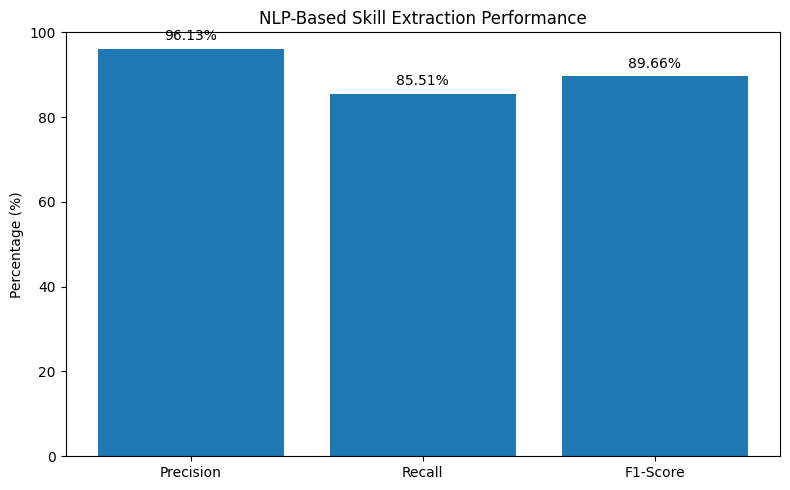

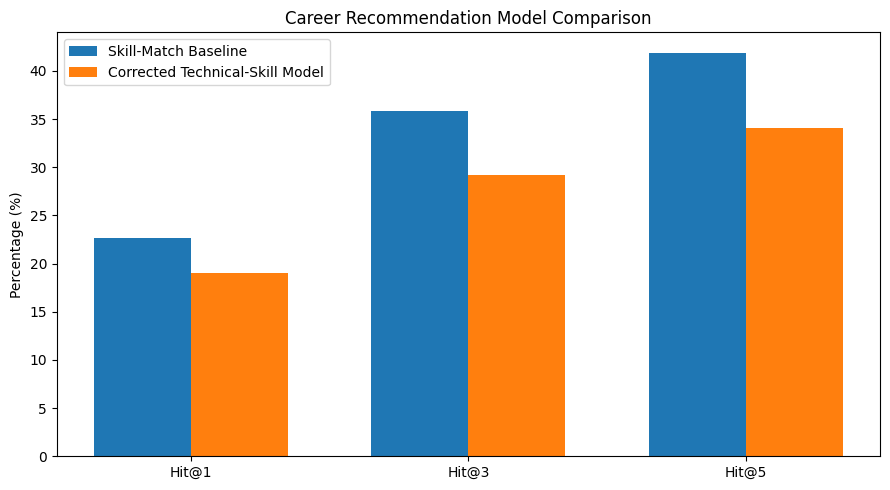

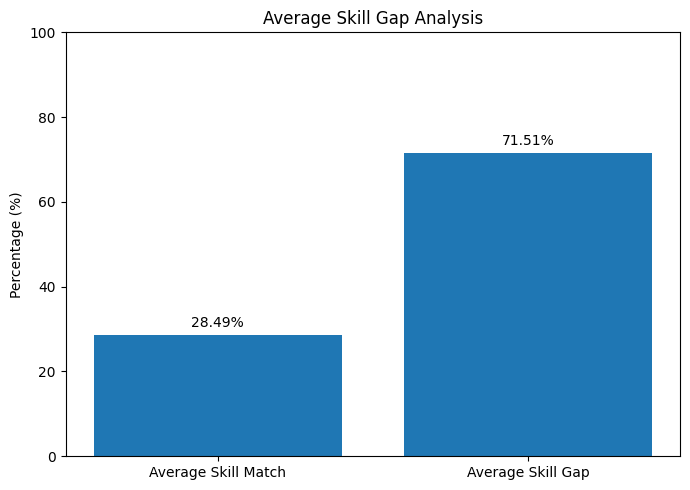

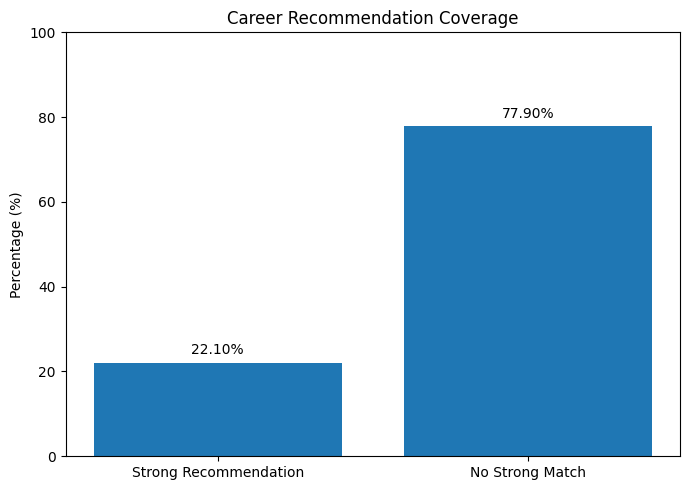


FINAL PAPER FILES
corrected_recommendation_evaluation.csv
figure1_skill_extraction_performance.png
figure2_recommendation_comparison.png
figure3_skill_gap_analysis.png
figure4_recommendation_coverage.png
final_corrected_evaluation_metrics.csv
paper_results_summary.csv
recommendation_coverage.csv
recommendation_model_comparison.csv
skill_extraction_results.csv
skill_gap_results.csv

ALL PAPER RESULTS GENERATED SUCCESSFULLY


In [ ]:
# ============================================================
# FINAL PAPER-READY RESULTS, COMPARISON TABLES AND FIGURES
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

final_output_dir = "/content/final_project_results"
os.makedirs(final_output_dir, exist_ok=True)

print("=" * 70)
print("FINAL PAPER RESULTS GENERATION")
print("=" * 70)


# ============================================================
# 1. RECOMMENDATION MODEL COMPARISON
# ============================================================

baseline = {
    "Model": "Skill-Match Baseline",
    "Hit@1 (%)": 22.65,
    "Hit@3 (%)": 35.85,
    "Hit@5 (%)": 41.90,
    "MRR": 0.3224
}

corrected = {
    "Model": "Corrected Technical-Skill Model",
    "Hit@1 (%)": 19.05,
    "Hit@3 (%)": 29.20,
    "Hit@5 (%)": 34.05,
    "MRR": 0.2584
}

recommendation_comparison = pd.DataFrame([
    baseline,
    corrected
])

print()
print("=" * 70)
print("RECOMMENDATION MODEL COMPARISON")
print("=" * 70)

display(recommendation_comparison)


# Save
recommendation_comparison.to_csv(
    f"{final_output_dir}/recommendation_model_comparison.csv",
    index=False
)


# ============================================================
# 2. SKILL EXTRACTION RESULTS
# ============================================================

skill_extraction_results = pd.DataFrame([{
    "Metric": "Precision",
    "Value (%)": 96.13
}, {
    "Metric": "Recall",
    "Value (%)": 85.51
}, {
    "Metric": "F1-Score",
    "Value (%)": 89.66
}])

print()
print("=" * 70)
print("NLP SKILL EXTRACTION RESULTS")
print("=" * 70)

display(skill_extraction_results)

skill_extraction_results.to_csv(
    f"{final_output_dir}/skill_extraction_results.csv",
    index=False
)


# ============================================================
# 3. SKILL GAP RESULTS
# ============================================================

skill_gap_results = pd.DataFrame([{
    "Metric": "Average Skill Match (%)",
    "Value": 28.49
}, {
    "Metric": "Average Skill Gap (%)",
    "Value": 71.51
}, {
    "Metric": "Average Matching Skills",
    "Value": 1.71
}, {
    "Metric": "Average Missing Skills",
    "Value": 4.29
}, {
    "Metric": "Test Resumes",
    "Value": 2000
}])

print()
print("=" * 70)
print("SKILL GAP ANALYSIS RESULTS")
print("=" * 70)

display(skill_gap_results)

skill_gap_results.to_csv(
    f"{final_output_dir}/skill_gap_results.csv",
    index=False
)


# ============================================================
# 4. STRONG RECOMMENDATION COVERAGE
# ============================================================

coverage_results = pd.DataFrame([{
    "Recommendation Status": "Strong Career Recommendation",
    "Count": 442,
    "Percentage (%)": 22.10
}, {
    "Recommendation Status": "No Strong Career Match",
    "Count": 1558,
    "Percentage (%)": 77.90
}])

print()
print("=" * 70)
print("RECOMMENDATION COVERAGE")
print("=" * 70)

display(coverage_results)

coverage_results.to_csv(
    f"{final_output_dir}/recommendation_coverage.csv",
    index=False
)


# ============================================================
# 5. PAPER SUMMARY TABLE
# ============================================================

paper_summary = pd.DataFrame([
    {
        "Component": "NLP Skill Extraction",
        "Dataset Size": "10,000 resumes",
        "Primary Metric": "F1-Score",
        "Result": "89.66%"
    },
    {
        "Component": "Skill Extraction Precision",
        "Dataset Size": "10,000 resumes",
        "Primary Metric": "Precision",
        "Result": "96.13%"
    },
    {
        "Component": "Skill Extraction Recall",
        "Dataset Size": "10,000 resumes",
        "Primary Metric": "Recall",
        "Result": "85.51%"
    },
    {
        "Component": "Skill Gap Analysis",
        "Dataset Size": "2,000 test resumes",
        "Primary Metric": "Average Match",
        "Result": "28.49%"
    },
    {
        "Component": "Career Recommendation Baseline",
        "Dataset Size": "2,000 test resumes",
        "Primary Metric": "Hit@1",
        "Result": "22.65%"
    },
    {
        "Component": "Career Recommendation Baseline",
        "Dataset Size": "2,000 test resumes",
        "Primary Metric": "MRR",
        "Result": "0.3224"
    },
    {
        "Component": "Corrected Recommendation",
        "Dataset Size": "2,000 test resumes",
        "Primary Metric": "Hit@1",
        "Result": "19.05%"
    },
    {
        "Component": "Corrected Recommendation",
        "Dataset Size": "2,000 test resumes",
        "Primary Metric": "Strong Match Coverage",
        "Result": "22.10%"
    }
])

print()
print("=" * 70)
print("PAPER SUMMARY TABLE")
print("=" * 70)

display(paper_summary)

paper_summary.to_csv(
    f"{final_output_dir}/paper_results_summary.csv",
    index=False
)


# ============================================================
# 6. FIGURE 1 — SKILL EXTRACTION METRICS
# ============================================================

plt.figure(figsize=(8, 5))

metrics = [
    "Precision",
    "Recall",
    "F1-Score"
]

values = [
    96.13,
    85.51,
    89.66
]

plt.bar(metrics, values)

plt.ylabel("Percentage (%)")
plt.title("NLP-Based Skill Extraction Performance")
plt.ylim(0, 100)

for i, value in enumerate(values):
    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{final_output_dir}/figure1_skill_extraction_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE 2 — RECOMMENDATION COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

x = np.arange(3)

baseline_values = [
    22.65,
    35.85,
    41.90
]

corrected_values = [
    19.05,
    29.20,
    34.05
]

width = 0.35

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Skill-Match Baseline"
)

plt.bar(
    x + width / 2,
    corrected_values,
    width,
    label="Corrected Technical-Skill Model"
)

plt.xticks(
    x,
    ["Hit@1", "Hit@3", "Hit@5"]
)

plt.ylabel("Percentage (%)")
plt.title("Career Recommendation Model Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    f"{final_output_dir}/figure2_recommendation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. FIGURE 3 — SKILL GAP
# ============================================================

plt.figure(figsize=(7, 5))

gap_labels = [
    "Average Skill Match",
    "Average Skill Gap"
]

gap_values = [
    28.49,
    71.51
]

plt.bar(
    gap_labels,
    gap_values
)

plt.ylabel("Percentage (%)")
plt.title("Average Skill Gap Analysis")
plt.ylim(0, 100)

for i, value in enumerate(gap_values):
    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{final_output_dir}/figure3_skill_gap_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. FIGURE 4 — RECOMMENDATION COVERAGE
# ============================================================

plt.figure(figsize=(7, 5))

coverage_labels = [
    "Strong Recommendation",
    "No Strong Match"
]

coverage_values = [
    22.10,
    77.90
]

plt.bar(
    coverage_labels,
    coverage_values
)

plt.ylabel("Percentage (%)")
plt.title("Career Recommendation Coverage")

plt.ylim(0, 100)

for i, value in enumerate(coverage_values):
    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{final_output_dir}/figure4_recommendation_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. FINAL FILE LIST
# ============================================================

print()
print("=" * 70)
print("FINAL PAPER FILES")
print("=" * 70)

for file in sorted(os.listdir(final_output_dir)):
    print(file)

print()
print("=" * 70)
print("ALL PAPER RESULTS GENERATED SUCCESSFULLY")
print("=" * 70)

BACKEND


In [6]:
import os

print("ZIP files in /content:")
for f in os.listdir("/content"):
    if f.lower().endswith(".zip"):
        print("✅", f)

ZIP files in /content:
✅ archive.zip
✅ archive (2) (1).zip


In [8]:
# ============================================================
# STEP 1: FLASK BACKEND SETUP
# ============================================================
import os

print("ZIP files in /content:")
for f in os.listdir("/content"):
    if f.lower().endswith(".zip"):
        print("✅", f)
!pip -q install flask flask-cors pyngrok

import os
import json
import pandas as pd
import numpy as np

from flask import Flask, request, jsonify
from flask_cors import CORS

# Create Flask application
app = Flask(__name__)
CORS(app)

# Project directories
BASE_DIR = "/content"
RESUME_DIR = "/content/archive (2) (1).zip"
JOB_DIR = "/content/archive.zip"
RESULT_DIR = "/content/final_project_results"

# Check important project files
required_files = {
    "Resume Dataset": f"{RESUME_DIR}/training_data.csv",
    "Skills List": f"{RESUME_DIR}/skills_list.csv",
    "Job Roles": f"{RESUME_DIR}/job_roles.csv",
    "Job Descriptions": f"{JOB_DIR}/job_description.csv",
    "O*NET Software Skills": f"{BASE_DIR}/software_skills.csv",
    "O*NET Occupations": f"{BASE_DIR}/occupation_data.csv"
}

print("=" * 65)
print("BACKEND SETUP")
print("=" * 65)

for name, path in required_files.items():
    if os.path.exists(path):
        print(f"✅ {name}: Found")
    else:
        print(f"❌ {name}: NOT FOUND")

print()
print("Flask application created successfully.")
print("CORS enabled for frontend-backend communication.")
print("=" * 65)

ZIP files in /content:
✅ archive.zip
✅ archive (2) (1).zip
BACKEND SETUP
❌ Resume Dataset: NOT FOUND
❌ Skills List: NOT FOUND
❌ Job Roles: NOT FOUND
❌ Job Descriptions: NOT FOUND
✅ O*NET Software Skills: Found
✅ O*NET Occupations: Found

Flask application created successfully.
CORS enabled for frontend-backend communication.


In [9]:
import os
import zipfile

zip_files = [
    "/content/archive.zip",
    "/content/archive (2) (1).zip"
]

for zip_path in zip_files:
    print("\n" + "=" * 70)
    print("ZIP:", os.path.basename(zip_path))
    print("=" * 70)

    with zipfile.ZipFile(zip_path, "r") as z:
        files = z.namelist()

        print("Number of files:", len(files))
        print("\nFirst 30 files:")
        for f in files[:30]:
            print(f)

print("\nZIP inspection completed.")


ZIP: archive.zip
Number of files: 5

First 30 files:
job_roles.csv
skills_database.json
skills_list.csv
test_resumes.json
training_data.csv

ZIP: archive (2) (1).zip
Number of files: 2

First 30 files:
job_description.csv
job_postings.csv

ZIP inspection completed.


In [10]:
import os
import zipfile
import shutil

# ============================================================
# STEP 2: RESTORE PROJECT DATASETS
# ============================================================

resume_dir = "/content/resume_dataset"
job_dir = "/content/job_market_dataset"

# Remove old incomplete folders if they exist
if os.path.exists(resume_dir):
    shutil.rmtree(resume_dir)

if os.path.exists(job_dir):
    shutil.rmtree(job_dir)

# Create folders
os.makedirs(resume_dir, exist_ok=True)
os.makedirs(job_dir, exist_ok=True)

# Extract resume dataset
with zipfile.ZipFile("/content/archive.zip", "r") as z:
    z.extractall(resume_dir)

# Extract job-market dataset
with zipfile.ZipFile("/content/archive (2) (1).zip", "r") as z:
    z.extractall(job_dir)

print("=" * 70)
print("DATASETS RESTORED")
print("=" * 70)

print("\nResume Dataset:")
for file in sorted(os.listdir(resume_dir)):
    print("✅", file)

print("\nJob Market Dataset:")
for file in sorted(os.listdir(job_dir)):
    print("✅", file)

print("\n" + "=" * 70)
print("RESTORATION COMPLETED")
print("=" * 70)

DATASETS RESTORED

Resume Dataset:
✅ job_roles.csv
✅ skills_database.json
✅ skills_list.csv
✅ test_resumes.json
✅ training_data.csv

Job Market Dataset:
✅ job_description.csv
✅ job_postings.csv

RESTORATION COMPLETED


In [11]:
# ============================================================
# STEP 3: LOAD PROJECT DATA INTO BACKEND
# ============================================================

import pandas as pd
import json
import re
from collections import Counter

# Load datasets
training_data = pd.read_csv(
    "/content/resume_dataset/training_data.csv"
)

skills_df = pd.read_csv(
    "/content/resume_dataset/skills_list.csv"
)

job_roles_df = pd.read_csv(
    "/content/resume_dataset/job_roles.csv"
)

job_description_df = pd.read_csv(
    "/content/job_market_dataset/job_description.csv"
)

# Load skill names
skill_list = (
    skills_df["Skill Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)

print("=" * 70)
print("BACKEND DATA LOADING")
print("=" * 70)

print(f"Training resumes      : {len(training_data)}")
print(f"Available skills      : {len(skill_list)}")
print(f"Job roles             : {len(job_roles_df)}")
print(f"Job descriptions      : {len(job_description_df)}")

print("\nTraining data columns:")
print(list(training_data.columns))

print("\nJob role columns:")
print(list(job_roles_df.columns))

print("\nFirst 10 skills:")
print(skill_list[:10])

print("\n" + "=" * 70)
print("ALL DATASETS LOADED SUCCESSFULLY")
print("=" * 70)

BACKEND DATA LOADING
Training resumes      : 10000
Available skills      : 120
Job roles             : 324
Job descriptions      : 325

Training data columns:
['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills', 'Job Role', 'Category']

Job role columns:
['Job Title', 'Category', 'Education Requirement', 'Experience Years', 'Required Skills', 'Salary Range']

First 10 skills:
['Python', 'Java', 'JavaScript', 'C++', 'C#', 'Ruby', 'PHP', 'Go', 'Rust', 'TypeScript']

ALL DATASETS LOADED SUCCESSFULLY


In [12]:
# ============================================================
# STEP 4: NLP-BASED SKILL EXTRACTION
# ============================================================

def clean_text(text):
    """
    Clean resume/job text before skill extraction.
    """
    text = str(text).lower()

    # Keep letters, numbers and common programming symbols
    text = re.sub(r"[^a-zA-Z0-9+#./ -]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_skills(text, skill_list):
    """
    Extract known skills from resume text using
    case-insensitive exact phrase matching.
    """

    text = clean_text(text)

    found_skills = []

    for skill in skill_list:

        skill_clean = clean_text(skill)

        # Match complete words/phrases
        pattern = r"(?<!\w)" + re.escape(skill_clean) + r"(?!\w)"

        if re.search(pattern, text):
            found_skills.append(skill)

    return sorted(set(found_skills))


# ------------------------------------------------------------
# Test with one resume from the dataset
# ------------------------------------------------------------

sample_resume = training_data.iloc[0]["Resume Text"]

extracted_skills = extract_skills(
    sample_resume,
    skill_list
)

print("=" * 70)
print("NLP SKILL EXTRACTION TEST")
print("=" * 70)

print("\nSample Resume:")
print(sample_resume)

print("\nExtracted Skills:")
print(extracted_skills)

print("\nNumber of Extracted Skills:")
print(len(extracted_skills))

print("\n" + "=" * 70)
print("SKILL EXTRACTION ENGINE READY")
print("=" * 70)

NLP SKILL EXTRACTION TEST

Sample Resume:
Education: Bachelor's in Computer Science Experience: 2 years Skills: Market Research, Maven, Java, REST API, Spring Boot, Microservices, Statistics, SQL

Extracted Skills:
['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']

Number of Extracted Skills:
6

SKILL EXTRACTION ENGINE READY


In [13]:
# ============================================================
# STEP 5: SKILL GAP ANALYSIS ENGINE
# ============================================================

def parse_required_skills(required_skills):
    """
    Convert the pipe-separated required skills
    into a clean list.
    """

    if pd.isna(required_skills):
        return []

    skills = str(required_skills).split("|")

    return [
        skill.strip()
        for skill in skills
        if skill.strip()
    ]


def calculate_skill_gap(candidate_skills, required_skills):
    """
    Calculate matching skills, missing skills,
    and skill match percentage.
    """

    candidate_set = {
        str(skill).strip().lower()
        for skill in candidate_skills
    }

    required_set = {
        str(skill).strip().lower()
        for skill in required_skills
    }

    matching = candidate_set.intersection(required_set)
    missing = required_set - candidate_set

    if len(required_set) > 0:
        match_percentage = (
            len(matching) / len(required_set)
        ) * 100
    else:
        match_percentage = 0

    return (
        round(match_percentage, 2),
        sorted(matching),
        sorted(missing)
    )


def analyze_skill_gap(candidate_skills, job_roles):
    """
    Compare candidate skills against every job role.
    """

    results = []

    for _, row in job_roles.iterrows():

        required_skills = parse_required_skills(
            row["Required Skills"]
        )

        match_percentage, matching, missing = (
            calculate_skill_gap(
                candidate_skills,
                required_skills
            )
        )

        results.append({
            "Job Role": row["Job Title"],
            "Category": row["Category"],
            "Skill Match (%)": match_percentage,
            "Matching Skills": matching,
            "Missing Skills": missing,
            "Required Skill Count": len(required_skills)
        })

    result_df = pd.DataFrame(results)

    # Rank roles from highest skill match to lowest
    result_df = result_df.sort_values(
        by="Skill Match (%)",
        ascending=False
    ).reset_index(drop=True)

    return result_df


# ------------------------------------------------------------
# Test with the sample candidate
# ------------------------------------------------------------

candidate_skills = extracted_skills

skill_gap_results = analyze_skill_gap(
    candidate_skills,
    job_roles_df
)

print("=" * 70)
print("SKILL GAP ANALYSIS TEST")
print("=" * 70)

print("\nCandidate Skills:")
print(candidate_skills)

print("\nTop 10 Recommended Roles Based on Skill Match:")
print(
    skill_gap_results[
        [
            "Job Role",
            "Category",
            "Skill Match (%)",
            "Matching Skills",
            "Missing Skills"
        ]
    ].head(10).to_string(index=False)
)

print("\n" + "=" * 70)
print("SKILL GAP ANALYSIS ENGINE READY")
print("=" * 70)

SKILL GAP ANALYSIS TEST

Candidate Skills:
['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']

Top 10 Recommended Roles Based on Skill Match:
                Job Role             Category  Skill Match (%)                      Matching Skills                                                                Missing Skills
  Java Backend Developer           Technology            66.67 [java, microservices, rest api, sql]                                                          [maven, spring boot]
        Python Developer           Technology            33.33                      [rest api, sql]                                      [django, flask, problem solving, python]
        Talend Developer     Data & Analytics            33.33                          [java, sql]                                 [data integration, data quality, etl, talend]
          Data Scientist           Technology            33.33                    [sql, statistics]                    

In [14]:
# ============================================================
# STEP 6: JOB MARKET SKILL TREND ANALYSIS
# ============================================================

# Combine available job-description text fields
text_columns = [
    "Description",
    "Benefits",
    "Requirement",
    "Requirements"
]

for col in text_columns:
    if col in job_description_df.columns:
        job_description_df[col] = (
            job_description_df[col]
            .fillna("")
            .astype(str)
        )

job_description_df["Job Text"] = (
    job_description_df["Description"] + " " +
    job_description_df["Benefits"] + " " +
    job_description_df["Requirement"] + " " +
    job_description_df["Requirements"]
)


# ------------------------------------------------------------
# Extract skills from each job description
# ------------------------------------------------------------

job_description_df["Extracted Skills"] = (
    job_description_df["Job Text"].apply(
        lambda text: extract_skills(text, skill_list)
    )
)


# ------------------------------------------------------------
# Count skill demand
# ------------------------------------------------------------

skill_demand = Counter()

for skills in job_description_df["Extracted Skills"]:
    for skill in skills:
        skill_demand[skill] += 1


# ------------------------------------------------------------
# Create market-skill dataframe
# ------------------------------------------------------------

market_skills = pd.DataFrame(
    skill_demand.items(),
    columns=["Skill", "Job_Count"]
)

market_skills = market_skills.sort_values(
    by="Job_Count",
    ascending=False
).reset_index(drop=True)


# Calculate demand percentage
total_jobs = len(job_description_df)

market_skills["Demand_Percentage"] = (
    market_skills["Job_Count"] / total_jobs * 100
).round(2)


# ------------------------------------------------------------
# Create reusable market-demand dictionary
# ------------------------------------------------------------

market_demand_dict = dict(
    zip(
        market_skills["Skill"].str.lower(),
        market_skills["Demand_Percentage"]
    )
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("JOB MARKET SKILL TREND ANALYSIS")
print("=" * 70)

print("\nTotal Job Descriptions:", total_jobs)

print(
    "Unique Skills Found in Job Market:",
    len(market_skills)
)

print("\nTop 20 In-Demand Skills:\n")

print(
    market_skills.head(20).to_string(index=False)
)

print("\n" + "=" * 70)
print("JOB MARKET ANALYSIS ENGINE READY")
print("=" * 70)

JOB MARKET SKILL TREND ANALYSIS

Total Job Descriptions: 325
Unique Skills Found in Job Market: 105

Top 20 In-Demand Skills:

             Skill  Job_Count  Demand_Percentage
     Communication        189              58.15
            Python        113              34.77
               SQL         91              28.00
             Agile         90              27.69
  Machine Learning         86              26.46
     Documentation         83              25.54
        Leadership         74              22.77
        Statistics         60              18.46
               AWS         57              17.54
             Azure         52              16.00
     Data Analysis         45              13.85
        Compliance         43              13.23
                Go         40              12.31
                 R         40              12.31
         Marketing         37              11.38
Project Management         36              11.08
        JavaScript         35           

In [15]:
# ============================================================
# STEP 7: DYNAMIC CAREER RECOMMENDATION ENGINE
# ============================================================

def calculate_market_score(required_skills):
    """
    Calculate average market demand of the skills
    required for a job role.
    """

    if not required_skills:
        return 0

    scores = []

    for skill in required_skills:

        skill_lower = str(skill).strip().lower()

        demand = market_demand_dict.get(
            skill_lower,
            0
        )

        scores.append(demand)

    return round(
        sum(scores) / len(scores),
        2
    )


def generate_dynamic_recommendations(
    candidate_skills,
    job_roles,
    skill_weight=0.70,
    market_weight=0.30
):
    """
    Generate career recommendations using:

    70% Skill Match
    30% Job Market Demand
    """

    skill_gap_df = analyze_skill_gap(
        candidate_skills,
        job_roles
    )

    recommendations = []

    for _, row in skill_gap_df.iterrows():

        required_skills = parse_required_skills(
            job_roles.loc[
                job_roles["Job Title"] == row["Job Role"],
                "Required Skills"
            ].iloc[0]
        )

        market_score = calculate_market_score(
            required_skills
        )

        skill_match = row["Skill Match (%)"]

        dynamic_score = (
            skill_weight * skill_match
            +
            market_weight * market_score
        )

        recommendations.append({
            "Job Role": row["Job Role"],
            "Category": row["Category"],
            "Skill Match (%)": skill_match,
            "Market Demand (%)": market_score,
            "Dynamic Score": round(dynamic_score, 2),
            "Matching Skills": row["Matching Skills"],
            "Missing Skills": row["Missing Skills"]
        })

    recommendation_df = pd.DataFrame(
        recommendations
    )

    recommendation_df = recommendation_df.sort_values(
        by="Dynamic Score",
        ascending=False
    ).reset_index(drop=True)

    return recommendation_df


# ------------------------------------------------------------
# Test Dynamic Recommendation
# ------------------------------------------------------------

dynamic_recommendations = generate_dynamic_recommendations(
    candidate_skills,
    job_roles_df
)

print("=" * 70)
print("DYNAMIC CAREER RECOMMENDATION TEST")
print("=" * 70)

print("\nCandidate Skills:")
print(candidate_skills)

print("\nTop 10 Dynamic Career Recommendations:\n")

print(
    dynamic_recommendations[
        [
            "Job Role",
            "Skill Match (%)",
            "Market Demand (%)",
            "Dynamic Score",
            "Matching Skills",
            "Missing Skills"
        ]
    ].head(10).to_string(index=False)
)

print("\n" + "=" * 70)
print("DYNAMIC RECOMMENDATION ENGINE READY")
print("=" * 70)

DYNAMIC CAREER RECOMMENDATION TEST

Candidate Skills:
['Java', 'Market Research', 'Microservices', 'REST API', 'SQL', 'Statistics']

Top 10 Dynamic Career Recommendations:

                 Job Role  Skill Match (%)  Market Demand (%)  Dynamic Score                      Matching Skills                                                            Missing Skills
   Java Backend Developer            66.67               6.77          48.70 [java, microservices, rest api, sql]                                                      [maven, spring boot]
           Data Scientist            33.33              21.49          29.78                    [sql, statistics]                     [data analysis, machine learning, python, tensorflow]
        Backend Developer            33.33              12.26          27.01                          [java, sql]                       [api development, database design, node.js, python]
         Python Developer            33.33              11.69          26.8

In [16]:
# ============================================================
# STEP 8: EXPLAINABLE AI RECOMMENDATION LAYER
# ============================================================

def generate_explanation(row):
    """
    Generate a human-readable explanation
    for a career recommendation.
    """

    matching_skills = row["Matching Skills"]
    missing_skills = row["Missing Skills"]

    match_percentage = row["Skill Match (%)"]
    market_percentage = row["Market Demand (%)"]
    dynamic_score = row["Dynamic Score"]

    matching_count = len(matching_skills)
    missing_count = len(missing_skills)

    # Matching skill explanation
    if matching_count > 0:
        matching_text = ", ".join(
            skill.title()
            for skill in matching_skills
        )
    else:
        matching_text = "No major matching skills"

    # Missing skill explanation
    if missing_count > 0:
        missing_text = ", ".join(
            skill.title()
            for skill in missing_skills
        )
    else:
        missing_text = "No major missing skills"

    explanation = (
        f"{row['Job Role']} is recommended because "
        f"{matching_count} required skills match the candidate profile "
        f"({match_percentage:.2f}% skill match). "
        f"The average market demand of the required skills is "
        f"{market_percentage:.2f}%. "
        f"Matching skills include: {matching_text}. "
        f"To become better prepared for this role, the candidate "
        f"should develop: {missing_text}. "
        f"The resulting dynamic recommendation score is "
        f"{dynamic_score:.2f}."
    )

    return explanation


# ------------------------------------------------------------
# Generate explanations for all recommendations
# ------------------------------------------------------------

explainable_recommendations = (
    dynamic_recommendations.copy()
)

explainable_recommendations["Explanation"] = (
    explainable_recommendations.apply(
        generate_explanation,
        axis=1
    )
)


# ------------------------------------------------------------
# Display top recommendations with explanations
# ------------------------------------------------------------

print("=" * 70)
print("EXPLAINABLE AI RECOMMENDATION TEST")
print("=" * 70)

for i, row in explainable_recommendations.head(5).iterrows():

    print(f"\nRecommendation #{i + 1}")
    print("-" * 70)

    print("Job Role        :", row["Job Role"])
    print("Skill Match     :", row["Skill Match (%)"], "%")
    print("Market Demand   :", row["Market Demand (%)"], "%")
    print("Dynamic Score   :", row["Dynamic Score"])

    print("\nMatching Skills :")
    print(row["Matching Skills"])

    print("\nMissing Skills  :")
    print(row["Missing Skills"])

    print("\nExplanation:")
    print(row["Explanation"])


print("\n" + "=" * 70)
print("EXPLAINABLE AI LAYER READY")
print("=" * 70)

EXPLAINABLE AI RECOMMENDATION TEST

Recommendation #1
----------------------------------------------------------------------
Job Role        : Java Backend Developer
Skill Match     : 66.67 %
Market Demand   : 6.77 %
Dynamic Score   : 48.7

Matching Skills :
['java', 'microservices', 'rest api', 'sql']

Missing Skills  :
['maven', 'spring boot']

Explanation:
Java Backend Developer is recommended because 4 required skills match the candidate profile (66.67% skill match). The average market demand of the required skills is 6.77%. Matching skills include: Java, Microservices, Rest Api, Sql. To become better prepared for this role, the candidate should develop: Maven, Spring Boot. The resulting dynamic recommendation score is 48.70.

Recommendation #2
----------------------------------------------------------------------
Job Role        : Data Scientist
Skill Match     : 33.33 %
Market Demand   : 21.49 %
Dynamic Score   : 29.78

Matching Skills :
['sql', 'statistics']

Missing Skills  :
[

In [17]:
# ============================================================
# STEP 9: DYNAMIC SKILL / LEARNING ROADMAP
# ============================================================

def normalize_skill(skill):
    """
    Normalize skill names for matching between
    job-role requirements and market data.
    """
    return str(skill).strip().lower()


def calculate_skill_priority(
    missing_skills,
    market_demand_dict
):
    """
    Calculate learning priority for missing skills.

    Priority is based on:
    1. Skill gap occurrence
    2. Job market demand
    """

    roadmap = []

    for skill in missing_skills:

        normalized_skill = normalize_skill(skill)

        market_demand = market_demand_dict.get(
            normalized_skill,
            0
        )

        roadmap.append({
            "Missing Skill": skill,
            "Market Demand (%)": market_demand
        })

    return pd.DataFrame(roadmap)


# ------------------------------------------------------------
# Generate roadmap for top recommendation
# ------------------------------------------------------------

top_recommendation = (
    explainable_recommendations.iloc[0]
)

top_missing_skills = (
    top_recommendation["Missing Skills"]
)

roadmap_df = calculate_skill_priority(
    top_missing_skills,
    market_demand_dict
)


# ------------------------------------------------------------
# Calculate dynamic priority
# ------------------------------------------------------------

if len(roadmap_df) > 0:

    # Normalize market demand to 0-100
    max_demand = roadmap_df["Market Demand (%)"].max()

    if max_demand > 0:
        roadmap_df["Market Demand Score"] = (
            roadmap_df["Market Demand (%)"]
            / max_demand
            * 100
        )
    else:
        roadmap_df["Market Demand Score"] = 0

    # For this candidate, each missing skill occurs once.
    # Therefore the roadmap is primarily prioritized
    # by market demand.
    roadmap_df["Gap Frequency Score"] = 100

    roadmap_df["Dynamic Priority"] = (
        0.5 * roadmap_df["Gap Frequency Score"]
        +
        0.5 * roadmap_df["Market Demand Score"]
    )

    roadmap_df = roadmap_df.sort_values(
        by="Dynamic Priority",
        ascending=False
    ).reset_index(drop=True)


# ------------------------------------------------------------
# Display roadmap
# ------------------------------------------------------------

print("=" * 70)
print("DYNAMIC SKILL / LEARNING ROADMAP")
print("=" * 70)

print("\nRecommended Career Role:")
print(top_recommendation["Job Role"])

print("\nCurrent Matching Skills:")
print(top_recommendation["Matching Skills"])

print("\nSkills to Develop:")
print(top_missing_skills)

print("\nPrioritized Learning Roadmap:\n")

if len(roadmap_df) > 0:

    print(
        roadmap_df[
            [
                "Missing Skill",
                "Market Demand (%)",
                "Dynamic Priority"
            ]
        ].to_string(index=False)
    )

else:
    print("No missing skills identified.")

print("\n" + "=" * 70)
print("DYNAMIC LEARNING ROADMAP READY")
print("=" * 70)

DYNAMIC SKILL / LEARNING ROADMAP

Recommended Career Role:
Java Backend Developer

Current Matching Skills:
['java', 'microservices', 'rest api', 'sql']

Skills to Develop:
['maven', 'spring boot']

Prioritized Learning Roadmap:

Missing Skill  Market Demand (%)  Dynamic Priority
        maven                  0              50.0
  spring boot                  0              50.0

DYNAMIC LEARNING ROADMAP READY


In [18]:
# ============================================================
# STEP 10: CREATE MAIN /ANALYZE API ENDPOINT
# ============================================================

@app.route("/analyze", methods=["POST"])
def analyze_resume():

    try:

        # ----------------------------------------------------
        # 1. Receive request
        # ----------------------------------------------------

        data = request.get_json()

        if not data:
            return jsonify({
                "success": False,
                "error": "No JSON data received."
            }), 400

        resume_text = data.get("resume_text", "")

        if not resume_text.strip():
            return jsonify({
                "success": False,
                "error": "Resume text is empty."
            }), 400


        # ----------------------------------------------------
        # 2. NLP Skill Extraction
        # ----------------------------------------------------

        candidate_skills = extract_skills(
            resume_text,
            skill_list
        )


        # ----------------------------------------------------
        # 3. Skill Gap Analysis
        # ----------------------------------------------------

        skill_gap_results = analyze_skill_gap(
            candidate_skills,
            job_roles_df
        )


        # ----------------------------------------------------
        # 4. Dynamic Career Recommendation
        # ----------------------------------------------------

        dynamic_results = generate_dynamic_recommendations(
            candidate_skills,
            job_roles_df
        )


        # ----------------------------------------------------
        # 5. Explainable AI
        # ----------------------------------------------------

        explainable_results = (
            dynamic_results.copy()
        )

        explainable_results["Explanation"] = (
            explainable_results.apply(
                generate_explanation,
                axis=1
            )
        )


        # ----------------------------------------------------
        # 6. Top recommendation
        # ----------------------------------------------------

        top = explainable_results.iloc[0]

        recommended_role = top["Job Role"]

        matching_skills = top["Matching Skills"]

        missing_skills = top["Missing Skills"]


        # ----------------------------------------------------
        # 7. Dynamic Learning Roadmap
        # ----------------------------------------------------

        roadmap_df = calculate_skill_priority(
            missing_skills,
            market_demand_dict
        )

        if len(roadmap_df) > 0:

            max_demand = (
                roadmap_df["Market Demand (%)"].max()
            )

            if max_demand > 0:

                roadmap_df["Market Demand Score"] = (
                    roadmap_df["Market Demand (%)"]
                    / max_demand
                    * 100
                )

            else:

                roadmap_df["Market Demand Score"] = 0

            roadmap_df["Gap Frequency Score"] = 100

            roadmap_df["Dynamic Priority"] = (
                0.5 *
                roadmap_df["Gap Frequency Score"]
                +
                0.5 *
                roadmap_df["Market Demand Score"]
            )

            roadmap_df = roadmap_df.sort_values(
                by="Dynamic Priority",
                ascending=False
            )

        else:

            roadmap_df = pd.DataFrame(
                columns=[
                    "Missing Skill",
                    "Market Demand (%)",
                    "Dynamic Priority"
                ]
            )


        # ----------------------------------------------------
        # 8. Convert roadmap to JSON format
        # ----------------------------------------------------

        roadmap = []

        for _, row in roadmap_df.iterrows():

            roadmap.append({
                "skill": row["Missing Skill"],
                "market_demand": float(
                    row["Market Demand (%)"]
                ),
                "priority": float(
                    row["Dynamic Priority"]
                )
            })


        # ----------------------------------------------------
        # 9. Prepare recommendations for frontend
        # ----------------------------------------------------

        recommendations = []

        for _, row in explainable_results.head(10).iterrows():

            recommendations.append({
                "job_role": row["Job Role"],
                "category": row["Category"],
                "skill_match": float(
                    row["Skill Match (%)"]
                ),
                "market_demand": float(
                    row["Market Demand (%)"]
                ),
                "dynamic_score": float(
                    row["Dynamic Score"]
                ),
                "matching_skills": row["Matching Skills"],
                "missing_skills": row["Missing Skills"],
                "explanation": row["Explanation"]
            })


        # ----------------------------------------------------
        # 10. Final API response
        # ----------------------------------------------------

        response = {

            "success": True,

            "candidate": {
                "skills": candidate_skills,
                "skill_count": len(candidate_skills)
            },

            "recommendation": {
                "job_role": recommended_role,
                "skill_match": float(
                    top["Skill Match (%)"]
                ),
                "market_demand": float(
                    top["Market Demand (%)"]
                ),
                "dynamic_score": float(
                    top["Dynamic Score"]
                ),
                "matching_skills": matching_skills,
                "missing_skills": missing_skills,
                "explanation": top["Explanation"]
            },

            "learning_roadmap": roadmap,

            "top_recommendations": recommendations
        }


        return jsonify(response)


    except Exception as e:

        return jsonify({
            "success": False,
            "error": str(e)
        }), 500


print("=" * 70)
print("FLASK API ENDPOINT CREATED")
print("=" * 70)

print("\nEndpoint:")
print("POST /analyze")

print("\nPipeline:")
print("Resume → NLP → Skill Gap → Market Trends")
print("       → Recommendation → Explainability")
print("       → Learning Roadmap")

print("\nBackend integration endpoint is ready.")
print("=" * 70)

FLASK API ENDPOINT CREATED

Endpoint:
POST /analyze

Pipeline:
Resume → NLP → Skill Gap → Market Trends
       → Recommendation → Explainability
       → Learning Roadmap

Backend integration endpoint is ready.


In [19]:
# ============================================================
# STEP 11: TEST /ANALYZE API
# ============================================================

# Sample resume for API testing
test_resume = """
I am a Computer Science graduate with 2 years of experience.
I have skills in Java, Spring Boot, Microservices, REST API,
SQL, Maven and Git. I have worked on backend application
development and database integration.
"""


# ------------------------------------------------------------
# Create test request
# ------------------------------------------------------------

with app.test_client() as client:

    response = client.post(
        "/analyze",
        json={
            "resume_text": test_resume
        }
    )


# ------------------------------------------------------------
# Display response
# ------------------------------------------------------------

print("=" * 70)
print("API TEST RESULT")
print("=" * 70)

print("\nHTTP Status Code:")
print(response.status_code)

print("\nAPI Response:\n")

result = response.get_json()

print(json.dumps(
    result,
    indent=2
))

print("\n" + "=" * 70)

if response.status_code == 200 and result.get("success"):

    print("✅ API TEST PASSED")
    print("✅ Resume processed successfully")
    print("✅ Skills extracted")
    print("✅ Career recommendation generated")
    print("✅ Explanation generated")
    print("✅ Learning roadmap generated")

else:

    print("❌ API TEST FAILED")

print("=" * 70)

API TEST RESULT

HTTP Status Code:
200

API Response:

{
  "candidate": {
    "skill_count": 4,
    "skills": [
      "Java",
      "Microservices",
      "REST API",
      "SQL"
    ]
  },
  "learning_roadmap": [
    {
      "market_demand": 0.0,
      "priority": 50.0,
      "skill": "maven"
    },
    {
      "market_demand": 0.0,
      "priority": 50.0,
      "skill": "spring boot"
    }
  ],
  "recommendation": {
    "dynamic_score": 48.7,
    "explanation": "Java Backend Developer is recommended because 4 required skills match the candidate profile (66.67% skill match). The average market demand of the required skills is 6.77%. Matching skills include: Java, Microservices, Rest Api, Sql. To become better prepared for this role, the candidate should develop: Maven, Spring Boot. The resulting dynamic recommendation score is 48.70.",
    "job_role": "Java Backend Developer",
    "market_demand": 6.77,
    "matching_skills": [
      "java",
      "microservices",
      "rest api",
  

In [20]:
# ============================================================
# STEP 12: START FLASK SERVER
# ============================================================

import threading
import time

def run_flask():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )


# Start Flask in background
flask_thread = threading.Thread(
    target=run_flask,
    daemon=True
)

flask_thread.start()

# Give the server time to start
time.sleep(3)

print("=" * 70)
print("FLASK SERVER STARTED")
print("=" * 70)

print("\nBackend server:")
print("http://127.0.0.1:5000")

print("\nAPI endpoint:")
print("POST http://127.0.0.1:5000/analyze")

print("\nServer is running in the background.")
print("=" * 70)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


FLASK SERVER STARTED

Backend server:
http://127.0.0.1:5000

API endpoint:
POST http://127.0.0.1:5000/analyze

Server is running in the background.


In [22]:
# ============================================================
# STEP 13A: CONFIGURE NGROK AUTHENTICATION
# ============================================================

from pyngrok import ngrok

# Paste your ngrok authtoken ONLY inside this Colab cell.
# Do NOT share the token in ChatGPT.
ngrok.set_auth_token("YOUR_TOKEN_HERE")

print("=" * 70)
print("NGROK AUTHENTICATION CONFIGURED")
print("=" * 70)

NGROK AUTHENTICATION CONFIGURED


In [23]:
# ============================================================
# STEP 13B: CREATE PUBLIC BACKEND URL
# ============================================================

ngrok.kill()

public_tunnel = ngrok.connect(5000, "http")

public_url = public_tunnel.public_url

print("=" * 70)
print("PUBLIC BACKEND URL CREATED")
print("=" * 70)

print("\nBackend URL:")
print(public_url)

print("\nAPI Endpoint:")
print(public_url + "/analyze")

print("\n" + "=" * 70)
print("KEEP THIS COLAB SESSION RUNNING")
print("=" * 70)

ERROR:pyngrok.process.ngrok:t=2026-09-11T08:11:44+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-09-11T08:11:44+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.

In [24]:
from pyngrok import ngrok

# Replace ONLY the text below with your actual ngrok authtoken
ngrok.set_auth_token("PASTE_YOUR_ACTUAL_TOKEN_HERE")

print("NGROK AUTH TOKEN CONFIGURED")

NGROK AUTH TOKEN CONFIGURED


In [26]:
from pyngrok import ngrok

ngrok.kill()

ngrok.set_auth_token("YOUR_REAL_TOKEN")

print("Real ngrok token configured")

Real ngrok token configured


In [27]:
ngrok.set_auth_token("your-long-real-token")

In [30]:
from pyngrok import ngrok

ngrok.kill()

# Paste the NEW ngrok v2/v3 authtoken here
ngrok.set_auth_token("YOUR_NEW_TOKEN")

print("NEW NGROK TOKEN CONFIGURED")

NEW NGROK TOKEN CONFIGURED


In [32]:
from pyngrok import ngrok

ngrok.kill()

print("Old ngrok session cleared")

Old ngrok session cleared


In [33]:
from pyngrok import ngrok

# Paste your ACTUAL ngrok authtoken between the quotes
ngrok.set_auth_token("PASTE_YOUR_ACTUAL_NGROK_TOKEN_HERE")

print("NGROK TOKEN CONFIGURED")

NGROK TOKEN CONFIGURED


In [34]:
from pyngrok import ngrok

ngrok.set_auth_token("3JAxNDfzV53ktkDmbHKBlrB7vXM_7vRH1WHLRGm4xpbQ9CUqx")

print("NGROK TOKEN CONFIGURED")

NGROK TOKEN CONFIGURED


In [35]:
from pyngrok import ngrok

ngrok.kill()

public_tunnel = ngrok.connect(5000, "http")

public_url = public_tunnel.public_url

print("=" * 60)
print("PUBLIC BACKEND URL CREATED")
print("=" * 60)

print("\nBackend URL:")
print(public_url)

print("\nAPI Endpoint:")
print(public_url + "/analyze")

PUBLIC BACKEND URL CREATED

Backend URL:
https://reconfirm-accurate-trade.ngrok-free.dev

API Endpoint:
https://reconfirm-accurate-trade.ngrok-free.dev/analyze


In [36]:
!pip -q install pypdf python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.0 MB/s eta 0:00:00


In [37]:
import io
from pypdf import PdfReader
from docx import Document

def extract_resume_text(file_bytes, filename):
    """
    Extract text from PDF or DOCX resume.
    """

    filename = filename.lower()

    # PDF
    if filename.endswith(".pdf"):
        reader = PdfReader(io.BytesIO(file_bytes))

        text = ""

        for page in reader.pages:
            page_text = page.extract_text()

            if page_text:
                text += page_text + "\n"

        return text.strip()

    # DOCX
    elif filename.endswith(".docx"):
        document = Document(io.BytesIO(file_bytes))

        text = "\n".join(
            paragraph.text
            for paragraph in document.paragraphs
            if paragraph.text.strip()
        )

        return text.strip()

    else:
        raise ValueError(
            "Unsupported file format. Please upload PDF or DOCX."
        )


print("PDF/DOCX TEXT EXTRACTION READY")

PDF/DOCX TEXT EXTRACTION READY


In [39]:
# Allow adding the new route to the already-running Flask app
app._got_first_request = False

@app.route("/analyze-file", methods=["POST"])
def analyze_resume_file():

    try:

        if "resume" not in request.files:
            return jsonify({
                "success": False,
                "error": "No resume file uploaded."
            }), 400

        file = request.files["resume"]

        if file.filename == "":
            return jsonify({
                "success": False,
                "error": "No file selected."
            }), 400

        file_bytes = file.read()

        resume_text = extract_resume_text(
            file_bytes,
            file.filename
        )

        if not resume_text.strip():
            return jsonify({
                "success": False,
                "error": "Could not extract text from the resume."
            }), 400

        candidate_skills = extract_skills(
            resume_text,
            skill_list
        )

        dynamic_results = generate_dynamic_recommendations(
            candidate_skills,
            job_roles_df
        )

        explainable_results = dynamic_results.copy()

        explainable_results["Explanation"] = (
            explainable_results.apply(
                generate_explanation,
                axis=1
            )
        )

        top = explainable_results.iloc[0]

        matching_skills = top["Matching Skills"]
        missing_skills = top["Missing Skills"]

        roadmap_df = calculate_skill_priority(
            missing_skills,
            market_demand_dict
        )

        roadmap = []

        if len(roadmap_df) > 0:

            max_demand = roadmap_df["Market Demand (%)"].max()

            if max_demand > 0:
                roadmap_df["Market Demand Score"] = (
                    roadmap_df["Market Demand (%)"]
                    / max_demand * 100
                )
            else:
                roadmap_df["Market Demand Score"] = 0

            roadmap_df["Gap Frequency Score"] = 100

            roadmap_df["Dynamic Priority"] = (
                0.5 * roadmap_df["Gap Frequency Score"]
                +
                0.5 * roadmap_df["Market Demand Score"]
            )

            roadmap_df = roadmap_df.sort_values(
                by="Dynamic Priority",
                ascending=False
            )

            for _, row in roadmap_df.iterrows():

                roadmap.append({
                    "skill": row["Missing Skill"],
                    "market_demand": float(
                        row["Market Demand (%)"]
                    ),
                    "priority": float(
                        row["Dynamic Priority"]
                    )
                })

        recommendations = []

        for _, row in explainable_results.head(10).iterrows():

            recommendations.append({
                "job_role": row["Job Role"],
                "category": row["Category"],
                "skill_match": float(row["Skill Match (%)"]),
                "market_demand": float(row["Market Demand (%)"]),
                "dynamic_score": float(row["Dynamic Score"]),
                "matching_skills": row["Matching Skills"],
                "missing_skills": row["Missing Skills"],
                "explanation": row["Explanation"]
            })

        response = {

            "success": True,

            "candidate": {
                "skills": candidate_skills,
                "skill_count": len(candidate_skills)
            },

            "recommendation": {

                "job_role": top["Job Role"],
                "skill_match": float(top["Skill Match (%)"]),
                "market_demand": float(top["Market Demand (%)"]),
                "dynamic_score": float(top["Dynamic Score"]),

                "matching_skills": matching_skills,
                "missing_skills": missing_skills,

                "explanation": top["Explanation"]
            },

            "learning_roadmap": roadmap,

            "top_recommendations": recommendations
        }

        return jsonify(response)

    except Exception as e:

        return jsonify({
            "success": False,
            "error": str(e)
        }), 500


# Restore Flask's normal state
app._got_first_request = True

print("FILE ANALYSIS API CREATED")
print("Endpoint: POST /analyze-file")

FILE ANALYSIS API CREATED
Endpoint: POST /analyze-file


In [40]:
from docx import Document
import requests
import os
import json

# Create a temporary DOCX resume
doc = Document()

resume_text = """
Bada Usha Sri
+91 7075340518
badaushasri4@gmail.com
LinkedIn: https://www.linkedin.com/in/ushasri-bada-8a647521b

EDUCATION
SITAM, JNTU-GV, VZM, India.
B.Tech, Computer Science (AI&DS)
8.41 CGPA
May 2024

SKILLS
Analytical Tools: Power BI, Advanced Excel, Visualizations, Crystal Reports, Statistical modelling
Programming Languages: Java, Python, Apache Hive – HQL, HTML, CSS
Software: Data Analytics, Machine Learning, NLP, KERAS, JSON
Database: MySQL, Database Management System
Core Competencies: Analytical, Commit to excellence, Decision-making

INTERNSHIP EXPERIENCE

UNIFIED MENTOR PVT. LTD.
Data Science Intern - Analytics Business Insights
Feb 2024 – April 2024

Assisted in the collection, processing, and analysis of large datasets to identify trends and insights.
Developed and implemented statistical models to support business decision-making.
Utilized machine learning algorithms to improve predictive analytics and data-driven solutions.
Created visualizations and dashboards using Python and Tableau.

TAURIUS TECHNOLOGIES PVT. LTD.
Data Analytics Intern – Visualizations
Jun 2023 – Aug 2023

Collected, processed, and analyzed large datasets to identify patterns, trends, and insights.
Assisted in development and maintenance of dashboards and reports using Excel and Power BI.
Participated in team meetings and contributed to project planning and development.

KODNEST TECHNOLOGIES PVT. LTD.
Full Stack Java Intern
May 2023 – July 2023

Developed and maintained web applications using Java, Spring Boot, and Hibernate.
Implemented front-end features using HTML, CSS, JavaScript and React.
Designed and developed RESTful APIs for integration between front-end and back-end systems.
Collaborated with cross-functional teams.

ACADEMIC PROJECTS

Price Negotiation Chatbots using Machine Learning
Developed a machine learning model for price negotiation strategies in e-commerce chatbots.
Integrated NLP techniques to understand and respond to user inquiries.

Insurance Agency and Performance Analytics
Used Power BI and Excel to analyze Expense Ratio, Average Policy Size, Loss Ratio,
Cost per Quote and Net Profit Margin.

Statistical Analysis using Excel
Performed outlier analysis, boxplots, VLOOKUP, Chi-square, Normal Distribution and T-Distribution.

PUBLICATION
Price Negotiation Chatbots on E-Commerce Website Using Machine Learning.
Published in IJCRT, Volume 12 Issue 5, May 2024.
"""

for line in resume_text.strip().split("\n"):
    doc.add_paragraph(line)

test_file = "/content/test_resume.docx"
doc.save(test_file)

print("TEST DOCX CREATED")
print(test_file)

# Test the actual file-analysis API
api_url = "https://reconfirm-accurate-trade.ngrok-free.dev/analyze-file"

with open(test_file, "rb") as f:
    response = requests.post(
        api_url,
        files={
            "resume": (
                "test_resume.docx",
                f,
                "application/vnd.openxmlformats-officedocument.wordprocessingml.document"
            )
        }
    )

print("\nHTTP STATUS:", response.status_code)

result = response.json()

print("\nAPI TEST RESULT:")
print(json.dumps(result, indent=2))

TEST DOCX CREATED
/content/test_resume.docx


INFO:werkzeug:127.0.0.1 - - [11/Sep/2026 09:24:45] "POST /analyze-file HTTP/1.1" 200 -



HTTP STATUS: 200

API TEST RESULT:
{
  "candidate": {
    "skill_count": 11,
    "skills": [
      "CSS",
      "HTML",
      "Java",
      "JavaScript",
      "Machine Learning",
      "MySQL",
      "Negotiation",
      "Power BI",
      "Python",
      "React",
      "Tableau"
    ]
  },
  "learning_roadmap": [
    {
      "market_demand": 1.23,
      "priority": 100.0,
      "skill": "vue.js"
    },
    {
      "market_demand": 0.0,
      "priority": 50.0,
      "skill": "ui/ux design"
    }
  ],
  "recommendation": {
    "dynamic_score": 48.16,
    "explanation": "Frontend Developer is recommended because 4 required skills match the candidate profile (66.67% skill match). The average market demand of the required skills is 4.97%. Matching skills include: Css, Html, Javascript, React. To become better prepared for this role, the candidate should develop: Ui/Ux Design, Vue.Js. The resulting dynamic recommendation score is 48.16.",
    "job_role": "Frontend Developer",
    "market_d

In [41]:
# =====================================================
# MARKET TRENDS API
# =====================================================

# Allow adding a new route to the already-running Flask app
app._got_first_request = False


@app.route("/market-trends", methods=["GET"])
def get_market_trends():

    try:

        # Select top 15 market-demand skills
        trends = market_skills.head(15).copy()

        result = []

        for _, row in trends.iterrows():

            result.append({
                "skill": str(row["Skill"]),
                "job_count": int(row["Job_Count"]),
                "demand_percentage": float(row["Demand_Percentage"])
            })

        return jsonify({
            "success": True,
            "total_jobs": int(total_jobs),
            "trends": result
        })

    except Exception as e:

        return jsonify({
            "success": False,
            "error": str(e)
        }), 500


# Restore Flask state
app._got_first_request = True

print("MARKET TRENDS API CREATED")
print("Endpoint: GET /market-trends")

MARKET TRENDS API CREATED
Endpoint: GET /market-trends


In [44]:
import requests
import json

market_url = "https://reconfirm-accurate-trade.ngrok-free.dev/market-trends"

response = requests.get(market_url)

print("HTTP STATUS:", response.status_code)

result = response.json()

print("\nMARKET TRENDS RESULT:")
print(json.dumps(result, indent=2))

INFO:werkzeug:127.0.0.1 - - [11/Sep/2026 10:04:55] "GET /market-trends HTTP/1.1" 200 -


HTTP STATUS: 200

MARKET TRENDS RESULT:
{
  "success": true,
  "total_jobs": 325,
  "trends": [
    {
      "demand_percentage": 58.15,
      "job_count": 189,
      "skill": "Communication"
    },
    {
      "demand_percentage": 34.77,
      "job_count": 113,
      "skill": "Python"
    },
    {
      "demand_percentage": 28.0,
      "job_count": 91,
      "skill": "SQL"
    },
    {
      "demand_percentage": 27.69,
      "job_count": 90,
      "skill": "Agile"
    },
    {
      "demand_percentage": 26.46,
      "job_count": 86,
      "skill": "Machine Learning"
    },
    {
      "demand_percentage": 25.54,
      "job_count": 83,
      "skill": "Documentation"
    },
    {
      "demand_percentage": 22.77,
      "job_count": 74,
      "skill": "Leadership"
    },
    {
      "demand_percentage": 18.46,
      "job_count": 60,
      "skill": "Statistics"
    },
    {
      "demand_percentage": 17.54,
      "job_count": 57,
      "skill": "AWS"
    },
    {
      "demand_percentage":